# TARGET-ALL-P2: Pharmacogenomics of Thiopurine Metabolism (TPMT/NUDT15) and MRD Status

MSc thesis EDA/analysis notebook. Investigates whether TPMT and NUDT15 expression, and the broader thiopurine metabolism pathway, are associated with end-of-induction minimal residual disease (MRD) status in paediatric B-ALL (TARGET-ALL-P2 cohort).

**Contents**
1. Data acquisition (GDC API)
2. Extract TPMT/NUDT15 expression
3. TPMT/NUDT15 expression overview
4. Clinical data & MRD status
5. Merge expression with clinical data
6. Differential expression: MRD+ vs MRD− (PyDESeq2)
7. Gene Set Enrichment Analysis (GSEA)
8. Leading-edge pathway heatmap
9. ALLSorts molecular subtyping
10. Log-CPM normalisation, exploratory UMAP & sequencing-depth batch check
11. TPMT/NUDT15 expression vs MRD status and subtype
12. Ribosome & TNF pathway scores vs MRD status
13. GO Biological Process enrichment
14. Thiopurine pathway gene correlations
15. External clinical covariates (protocol, WBC, age, survival)
16. MRD classifiers (does gene expression add predictive value?)
17. Final depth-corrected UMAP, clustering & thesis figure

## 1. Data Acquisition
Retrieve all open-access gene expression file IDs for the TARGET-ALL-P2 project from the GDC API.

In [1]:
import requests
import json
import pandas as pd
import io


endpoint = "https://api.gdc.cancer.gov/files"
filters = json.dumps({
    "op": "and",
    "content": [
        {
            "op": "in",
            "content": {
                "field": "cases.project.project_id",
                "value": ["TARGET-ALL-P2"]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "data_type",
                "value": ["Gene Expression Quantification"]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "access",
                "value": ["open"]
            }
        },
    ]
})

params = {
    "filters": filters,
    "fields": "file_id,file_name,data_type,access,cases.submitter_id,cases.case_id",
    "format": "JSON",
    "size": "500"
}

response = requests.get(endpoint, params=params)
data = response.json()
files = data["data"]["hits"]

print(f"Found {len(files)} files\n")
print("First file structure:")
print(json.dumps(files[0], indent=2))

Found 500 files

First file structure:
{
  "id": "50b6d60d-faf6-4ac8-960d-e06cd7d1d929",
  "cases": [
    {
      "case_id": "bd9e8694-896f-5553-97c8-357c2ba6159a",
      "submitter_id": "TARGET-10-PAUCDY"
    }
  ],
  "access": "open",
  "file_name": "4915c991-29f0-494a-bf34-7cafa01ed781.rna_seq.augmented_star_gene_counts.tsv",
  "file_id": "50b6d60d-faf6-4ac8-960d-e06cd7d1d929",
  "data_type": "Gene Expression Quantification"
}


## 2. Extract TPMT and NUDT15 Expression
Map patient (case) submitter IDs to file IDs, spot-check the raw file format, then extract TPMT and NUDT15 TPM values across all downloaded batches into a single table.

In [2]:
file_map = {}
for f in files:
    sample_id = f["cases"][0]["submitter_id"]
    file_map[sample_id] = f["file_id"]

print(f"Example: {list(file_map.items())[0]}")

Example: ('TARGET-10-PAUCDY', '50b6d60d-faf6-4ac8-960d-e06cd7d1d929')


In [3]:
sample_name = list(file_map.keys())[0]
file_id = list(file_map.values())[0]

download_url = f"https://api.gdc.cancer.gov/data/{file_id}"
r = requests.get(download_url)

df_test = pd.read_csv(io.StringIO(r.text), sep="\t", comment="#")
print(df_test.head())
print("\nColumns:", df_test.columns.tolist())
print("\nShape:", df_test.shape)

              gene_id gene_name       gene_type  unstranded  stranded_first  \
0          N_unmapped       NaN             NaN     4481917         4481917   
1      N_multimapping       NaN             NaN     7160403         7160403   
2         N_noFeature       NaN             NaN    42207780        64211570   
3         N_ambiguous       NaN             NaN     3235411           40248   
4  ENSG00000000003.15    TSPAN6  protein_coding           2               1   

   stranded_second  tpm_unstranded  fpkm_unstranded  fpkm_uq_unstranded  
0          4481917             NaN              NaN                 NaN  
1          7160403             NaN              NaN                 NaN  
2         43099128             NaN              NaN                 NaN  
3          2410849             NaN              NaN                 NaN  
4                2          0.0717           0.0247              0.0236  

Columns: ['gene_id', 'gene_name', 'gene_type', 'unstranded', 'stranded_first', '

In [4]:
import tarfile
import os
import pandas as pd

# Extract all 5 batches 
os.makedirs("target_all_files", exist_ok=True)

for batch_num in range(1, 6):
    fname = f"target_all_batch{batch_num}.tar.gz"
    print(f"Extracting batch {batch_num}...")
    with tarfile.open(fname, "r:gz") as tar:
        tar.extractall("target_all_files/")

# Find all TSV files
all_files = []
for root, dirs, files_list in os.walk("target_all_files/"):
    for fname in files_list:
        if fname.endswith(".tsv"):
            all_files.append(os.path.join(root, fname))

# Parse TPMT and NUDT15
genes_of_interest = ["TPMT", "NUDT15"]
results = []

for i, fpath in enumerate(all_files):
    folder_name = os.path.basename(os.path.dirname(fpath))
    df = pd.read_csv(fpath, sep="\t", comment="#")
    df = df.dropna(subset=["gene_name"])
    gene_rows = df[df["gene_name"].isin(genes_of_interest)][["gene_name", "tpm_unstranded"]].copy()
    gene_rows["file_folder"] = folder_name
    results.append(gene_rows)

    if i % 50 == 0:
        print(f"Parsed {i+1}/{len(all_files)} files...")

# Combine and save 
expr_df = pd.concat(results, ignore_index=True)
expr_wide = expr_df.pivot(index="file_folder", columns="gene_name", values="tpm_unstranded")
expr_wide.columns.name = None
expr_wide = expr_wide.reset_index()

id_to_sample = {v: k for k, v in file_map.items()}
expr_wide["sample_id"] = expr_wide["file_folder"].map(id_to_sample)
expr_wide = expr_wide[["sample_id", "TPMT", "NUDT15"]]

print(expr_wide.head(10))
print(f"\nShape: {expr_wide.shape}")
print(f"\nMissing values:\n{expr_wide.isnull().sum()}")

expr_wide.to_csv("TPMT_NUDT15_expression.csv", index=False)
print("\nSaved to TPMT_NUDT15_expression.csv")

Extracting batch 1...


/var/folders/v_/j7694ws56vlb4hc0yb3b8xrr0000gn/T/ipykernel_54280/142248696.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("target_all_files/")


Extracting batch 2...
Extracting batch 3...
Extracting batch 4...
Extracting batch 5...
Parsed 1/437 files...
Parsed 51/437 files...
Parsed 101/437 files...
Parsed 151/437 files...
Parsed 201/437 files...
Parsed 251/437 files...
Parsed 301/437 files...
Parsed 351/437 files...
Parsed 401/437 files...
          sample_id     TPMT   NUDT15
0  TARGET-10-PATCJJ   2.6007  11.6051
1  TARGET-10-PARWLP   1.9779  39.1032
2  TARGET-10-PATBDK  10.2786  17.4217
3               NaN   6.8118  17.6931
4               NaN   3.8508  15.4670
5  TARGET-10-PARPNM   8.8417  15.8445
6  TARGET-10-PASIGB   9.0665  15.1204
7  TARGET-10-PATEHZ   3.9417  21.2298
8  TARGET-10-PATSIL   5.0864  38.9390
9  TARGET-10-PARJZZ   5.7437  10.8829

Shape: (437, 3)

Missing values:
sample_id    58
TPMT          0
NUDT15        0
dtype: int64

Saved to TPMT_NUDT15_expression.csv


## 3. TPMT/NUDT15 Expression Overview
Expression table is clean with TPMT and NUDT15 TPM values for 437 paediatric ALL patients. The data looks biologically sound, as NUDT15 expression values are higher than TPMT across most samples. This is consistent with published literature.

Summary statistics:
           TPMT    NUDT15
count  437.0000  437.0000
mean     6.0807   22.4598
std      4.1277   13.0743
min      0.0974    0.1846
25%      3.0921   13.5431
50%      5.0864   19.1449
75%      8.0711   29.1367
max     35.8954   99.9454


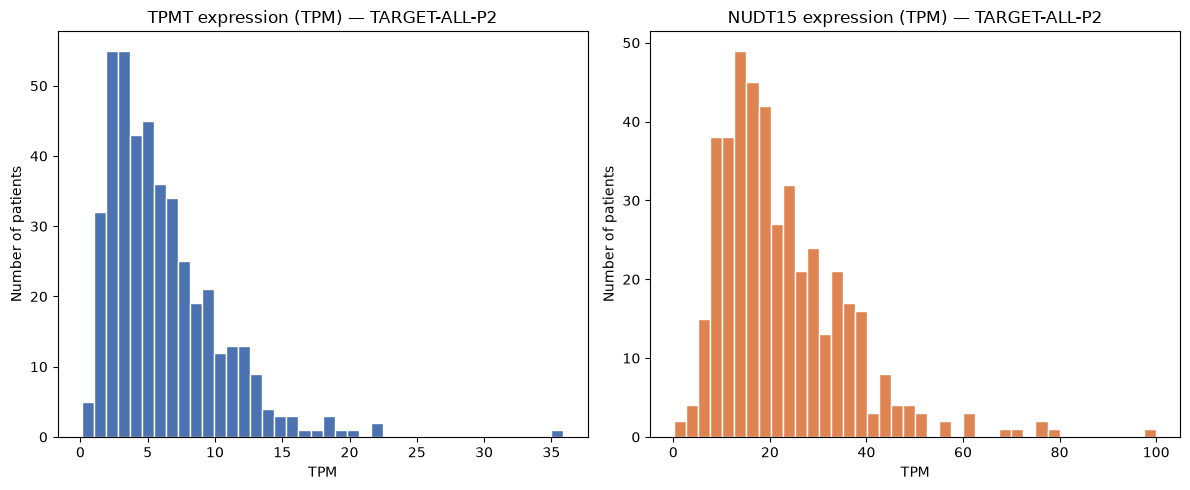

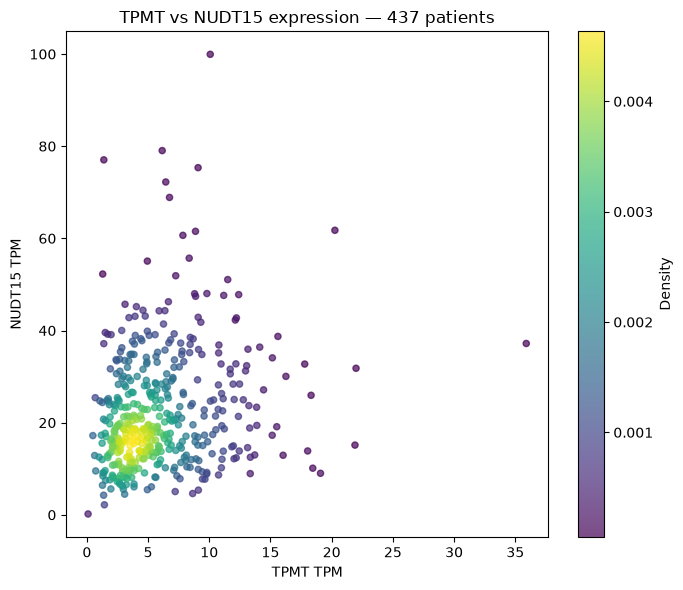

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import gaussian_kde
import numpy as np

expr_wide = pd.read_csv("TPMT_NUDT15_expression.csv")

print("Summary statistics:")
print(expr_wide[["TPMT", "NUDT15"]].describe().round(4))

#Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(expr_wide["TPMT"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("TPMT expression (TPM) — TARGET-ALL-P2")
axes[0].set_xlabel("TPM")
axes[0].set_ylabel("Number of patients")

axes[1].hist(expr_wide["NUDT15"], bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("NUDT15 expression (TPM) — TARGET-ALL-P2")
axes[1].set_xlabel("TPM")
axes[1].set_ylabel("Number of patients")

plt.tight_layout()
plt.savefig("TPMT_NUDT15_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

#Scatter plot
x = expr_wide["TPMT"]
y = expr_wide["NUDT15"]

# Calculate point density
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)

fig2, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(x, y, c=density, cmap="viridis", alpha=0.7, s=20)
plt.colorbar(scatter, ax=ax, label="Density")
ax.set_xlabel("TPMT TPM")
ax.set_ylabel("NUDT15 TPM")
ax.set_title("TPMT vs NUDT15 expression — 437 patients")
plt.tight_layout()
plt.savefig("TPMT_NUDT15_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Clinical Data & MRD Status
Pull clinical data for the same project and derive a binary end-of-induction MRD status (threshold 0.01%) per case.

In [6]:
all_cases = []
page_size = 100

for start in range(0, 1600, page_size):
    params = {
        "filters": json.dumps({
            "op": "=",
            "content": {"field": "project.project_id", "value": ["TARGET-ALL-P2"]}
        }),
        "fields": ",".join([
            "submitter_id",
            "case_id",
            "demographic.gender",
            "demographic.race",
            "demographic.ethnicity",
            "demographic.vital_status",
            "diagnoses.primary_diagnosis",
            "diagnoses.age_at_diagnosis",
            "diagnoses.days_to_last_follow_up",
            "diagnoses.morphology",
            "diagnoses.days_to_recurrence",
            "diagnoses.progression_or_recurrence",
            "diagnoses.treatments.therapeutic_agents",
            "diagnoses.treatments.treatment_outcome",
            "diagnoses.treatments.treatment_or_therapy",
            "follow_ups.disease_response",
            "follow_ups.days_to_follow_up",
            "follow_ups.molecular_tests.laboratory_test",
            "follow_ups.molecular_tests.test_result",
            "follow_ups.molecular_tests.test_value",
            "follow_ups.molecular_tests.days_to_test",
            "follow_ups.molecular_tests.timepoint_category",
        ]),
        "format": "JSON",
        "size": page_size,
        "from": start
    }
    r = requests.get("https://api.gdc.cancer.gov/cases", params=params)
    hits = r.json()["data"]["hits"]
    if not hits:
        break
    all_cases.extend(hits)
    print(f"Fetched {len(all_cases)} cases...")

print(f"\nDone. Total: {len(all_cases)}")

Fetched 100 cases...
Fetched 200 cases...
Fetched 300 cases...
Fetched 400 cases...
Fetched 500 cases...
Fetched 600 cases...
Fetched 700 cases...
Fetched 800 cases...
Fetched 900 cases...
Fetched 1000 cases...
Fetched 1100 cases...
Fetched 1200 cases...
Fetched 1300 cases...
Fetched 1400 cases...
Fetched 1500 cases...
Fetched 1587 cases...

Done. Total: 1587


#### 2. Parse clinical data and extract end-of-induction MRD status

In [7]:
rows = []

for case in all_cases:
    submitter_id = case.get("submitter_id")
    diag = case.get("diagnoses", [{}])[0]
    demo = case.get("demographic", {})

    # Extract treatments
    treatments = diag.get("treatments", [])
    agents = [t.get("therapeutic_agents") for t in treatments if t.get("therapeutic_agents")]
    outcomes = [t.get("treatment_outcome") for t in treatments if t.get("treatment_outcome")]

    # Extract MRD entries with timepoint
    mrd_entries = []
    disease_responses = []

    for fu in case.get("follow_ups", []):
        dr = fu.get("disease_response")
        if dr:
            disease_responses.append(dr)

        for mt in fu.get("molecular_tests", []):
            lab = mt.get("laboratory_test", "")
            if lab == "Minimal Residual Disease":
                mrd_entries.append({
                    "days_to_test": mt.get("days_to_test"),
                    "test_value": mt.get("test_value"),
                    "test_result": mt.get("test_result"),
                    "timepoint_category": mt.get("timepoint_category"),
                })

    # Sort by days_to_test to pick earliest 
    mrd_entries_sorted = sorted(
        [e for e in mrd_entries if e["days_to_test"] is not None],
        key=lambda x: x["days_to_test"]
    )
    if not mrd_entries_sorted:
        mrd_entries_sorted = mrd_entries

    # End of induction = typically day 29
    eoi_entries = [e for e in mrd_entries_sorted 
                   if e["days_to_test"] is not None and 15 <= e["days_to_test"] <= 50]
    
    target_entry = eoi_entries[0] if eoi_entries else (mrd_entries_sorted[0] if mrd_entries_sorted else None)

    mrd_value = target_entry["test_value"] if target_entry else None
    mrd_timepoint = target_entry["timepoint_category"] if target_entry else None
    mrd_days = target_entry["days_to_test"] if target_entry else None

    # Binary MRD: standard threshold 0.01% = 0.01
    if mrd_value is not None:
        mrd_status = "MRD_pos" if mrd_value >= 0.01 else "MRD_neg"
    else:
        mrd_status = None

    rows.append({
        "submitter_id": submitter_id,
        "gender": demo.get("gender"),
        "race": demo.get("race"),
        "ethnicity": demo.get("ethnicity"),
        "vital_status": demo.get("vital_status"),
        "age_at_diagnosis_days": diag.get("age_at_diagnosis"),
        "days_to_last_follow_up": diag.get("days_to_last_follow_up"),
        "morphology": diag.get("morphology"),
        "progression_or_recurrence": diag.get("progression_or_recurrence"),
        "therapeutic_agents": "; ".join(agents) if agents else None,
        "treatment_outcome": outcomes[0] if outcomes else None,
        "disease_response": disease_responses[0] if disease_responses else None,
        "mrd_value_eoi": mrd_value,
        "mrd_status": mrd_status,
        "mrd_days_to_test": mrd_days,
        "mrd_timepoint_category": mrd_timepoint,
        "n_mrd_entries": len(mrd_entries),
    })

clinical_df = pd.DataFrame(rows)
clinical_df["age_at_diagnosis_years"] = (
    clinical_df["age_at_diagnosis_days"] / 365.25
).round(1)

morphology_map = {
    "9835/3": "B-ALL", "9836/3": "B-ALL", "9811/3": "B-ALL",
    "9812/3": "B-ALL", "9813/3": "B-ALL", "9837/3": "T-ALL",
}
clinical_df["subtype"] = clinical_df["morphology"].map(morphology_map).fillna("Unknown")

clinical_df.to_csv("TARGET_ALL_P2_clinical.csv", index=False)

# Summary
print("=== MRD status ===")
print(clinical_df["mrd_status"].value_counts(dropna=False))
print("\n=== Subtype ===")
print(clinical_df["subtype"].value_counts(dropna=False))
print("\n=== Timepoint categories ===")
print(clinical_df["mrd_timepoint_category"].value_counts(dropna=False))
print("\n=== Treatment outcomes ===")
print(clinical_df["treatment_outcome"].value_counts(dropna=False))
print("\n=== Disease response ===")
print(clinical_df["disease_response"].value_counts(dropna=False))

=== MRD status ===
mrd_status
MRD_neg    689
NaN        565
MRD_pos    333
Name: count, dtype: int64

=== Subtype ===
subtype
B-ALL      1586
Unknown       1
Name: count, dtype: int64

=== Timepoint categories ===
mrd_timepoint_category
NaN                             1586
End of Consolidation Therapy       1
Name: count, dtype: int64

=== Treatment outcomes ===
treatment_outcome
None    1587
Name: count, dtype: int64

=== Disease response ===
disease_response
None    1587
Name: count, dtype: int64


There are 1022 cases with MRD status (689 MRD-negative, 333 MRD-positive), and 565 cases with no status will be excluded from the GSEA comparison. This cohort is made entirely of B-ALL (1586 of 1587 cases), aside from a single "Unknown" morphology call. Can't do B-ALL vs T-ALL comparison but can look at MRD+/MRD-. 

## 5. Merge Expression Data with Clinical Annotations
Build the full gene expression matrix (all genes, not just TPMT/NUDT15) and merge it with clinical/MRD annotations.

In [8]:
import os, glob

extract_dir = os.path.join(os.path.expanduser("~/PyCharmMiscProject"), "target_all_extracted")

all_tsvs = glob.glob(os.path.join(extract_dir, "**/*.tsv"), recursive=True)
print(f"Found {len(all_tsvs)} TSV files")

expr_dict = {}

for fpath in all_tsvs:
    file_id = os.path.basename(os.path.dirname(fpath))
    
    df = pd.read_csv(fpath, sep="\t", comment="#")
    df = df.dropna(subset=["gene_name"])
    df = df[~df["gene_id"].str.startswith("N_")]
    df = df.set_index("gene_name")["unstranded"]
    
    expr_dict[file_id] = df

expr_matrix = pd.DataFrame(expr_dict)  # genes × file_ids
print(f"Expression matrix shape: {expr_matrix.shape}")

# Map file_ids to submitter_ids
file_ids = list(expr_dict.keys())
id_map = {}

for i in range(0, len(file_ids), 100):
    batch = file_ids[i:i+100]
    params = {
        "filters": json.dumps({
            "op": "in",
            "content": {"field": "file_id", "value": batch}
        }),
        "fields": "file_id,cases.submitter_id",
        "format": "JSON",
        "size": 100
    }
    r = requests.get("https://api.gdc.cancer.gov/files", params=params)
    for f in r.json()["data"]["hits"]:
        cases = f.get("cases", [])
        if cases:
            id_map[f["file_id"]] = cases[0]["submitter_id"]
    print(f"Mapped {len(id_map)} so far...")

# Rename columns from file_id to submitter_id
expr_matrix.columns = [id_map.get(c, c) for c in expr_matrix.columns]

Found 437 TSV files
Expression matrix shape: (60660, 437)
Mapped 100 so far...
Mapped 200 so far...
Mapped 300 so far...
Mapped 400 so far...
Mapped 437 so far...


In [9]:
pycharm_dir = os.path.expanduser("~/PyCharmMiscProject")

clinical_df = pd.read_csv(f"{pycharm_dir}/TARGET_ALL_P2_clinical.csv")
expr_tpm = pd.read_csv(f"{pycharm_dir}/TPMT_NUDT15_expression.csv")

merged = expr_tpm.merge(
    clinical_df[["submitter_id", "mrd_status", "gender", "race",
                 "age_at_diagnosis_years", "subtype", "vital_status",
                 "mrd_value_eoi", "mrd_days_to_test"]],
    left_on="sample_id",
    right_on="submitter_id",
    how="inner"
)
merged_mrd = merged[merged["mrd_status"].isin(["MRD_pos", "MRD_neg"])].copy()
merged_mrd.to_csv(f"{pycharm_dir}/TARGET_ALL_P2_merged_MRD.csv", index=False)
print(f"merged_mrd saved: {merged_mrd.shape}")
print(merged_mrd["mrd_status"].value_counts())

mrd_samples = merged_mrd["sample_id"].tolist()
expr_mrd = expr_matrix[[c for c in expr_matrix.columns if c in mrd_samples]]
print(f"\nFinal expression matrix: {expr_mrd.shape}")
expr_mrd.to_csv(f"{pycharm_dir}/TARGET_ALL_P2_counts_MRD_samples.csv")


merged_mrd saved: (375, 12)
mrd_status
MRD_neg    243
MRD_pos    132
Name: count, dtype: int64

Final expression matrix: (60660, 375)


## 6. Differential Expression: MRD+ vs MRD− (PyDESeq2)

In [10]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
import numpy as np

# DESeq2 needs samples as rows, genes as columns (integer counts)
meta = merged_mrd[["sample_id", "mrd_status"]].set_index("sample_id")
meta = meta.loc[meta.index.isin(expr_mrd.columns)]

counts = expr_mrd[meta.index].T  # samples × genes
counts = counts.round().astype(int)
counts = counts.T.groupby(level=0).sum().T
counts = counts.loc[:, (counts > 0).any(axis=0)]

# Run DESeq2
inference = DefaultInference(n_cpus=4)
dds = DeseqDataSet(
    counts=counts,
    metadata=meta,
    design_factors="mrd_status",
    inference=inference
)
dds.deseq2()

stat_res = DeseqStats(dds, contrast=["mrd_status", "MRD_pos", "MRD_neg"], inference=inference)
stat_res.summary()
results_df = stat_res.results_df.dropna(subset=["stat"])
results_df.to_csv(f"{pycharm_dir}/TARGET_DE_results_MRDpos_vs_MRDneg.csv")

# Effect-size + significance filtering 
for lfc_cutoff in [0.585, 1.0, 1.5, 2.0]:
    n_05 = ((results_df['padj'] < 0.05) & (results_df['log2FoldChange'].abs() >= lfc_cutoff)).sum()
    n_01 = ((results_df['padj'] < 0.01) & (results_df['log2FoldChange'].abs() >= lfc_cutoff)).sum()
    print(f"|log2FC| >= {lfc_cutoff}: padj<0.05 -> {n_05} genes | padj<0.01 -> {n_01} genes")
print(f"\nDE results: {results_df.shape}")
print(results_df.sort_values("padj").head(10))

/var/folders/v_/j7694ws56vlb4hc0yb3b8xrr0000gn/T/ipykernel_54280/3185795760.py:17: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.24 seconds.

Fitting dispersions...
... done in 7.10 seconds.

Fitting dispersion trend curve...
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 7.59 seconds.

Fitting LFCs...
... done in 5.90 seconds.

Calculating cook's distance...
... done in 0.71 seconds.

Replacing 10263 outlier genes.

Fitting dispersions...
... done in 1.38 seconds.

Fitting MAP dispersions...
... done in 1.30 seconds.

Fitting LFCs...
... done in 1.22 seconds.

Running Wald tests...
... done in 0.99 seconds.



Log2 fold change & Wald test p-value: mrd_status MRD_pos vs MRD_neg
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_name                                                                     
5S_rRNA      26.395203        0.017603  0.135225  0.130172  0.896430  0.939909
5_8S_rRNA    15.256229       -1.159780  0.311693 -3.720899  0.000199  0.002566
7SK        1749.013392        0.194947  0.308207  0.632519  0.527048  0.676449
A1BG         86.836764       -0.380640  0.112306 -3.389309  0.000701  0.006454
A1BG-AS1    114.471184       -0.245346  0.089068 -2.754592  0.005877  0.029508
...                ...             ...       ...       ...       ...       ...
ZYX        3305.796655        0.681653  0.182625  3.732519  0.000190  0.002478
ZYXP1         0.058295       -0.046692  1.493110 -0.031272  0.975053       NaN
ZZEF1      5494.655560       -0.257319  0.065288 -3.941286  0.000081  0.001328
ZZZ3       2085.967141       -0.154640  0.066062 -2.340815  0.0

In [11]:
sig = results_df[results_df["padj"] < 0.05]
sig_strict = results_df[results_df["padj"] < 0.01]

up = sig[sig["log2FoldChange"] > 1]
down = sig[sig["log2FoldChange"] < -1]

print(f"Total genes tested: {len(results_df)}")
print(f"Significant genes (padj < 0.05): {len(sig)}")
print(f"Significant genes (padj < 0.01): {len(sig_strict)}")
print(f"Upregulated in MRD+ (LFC > 1, padj < 0.05): {len(up)}")
print(f"Downregulated in MRD+ (LFC < -1, padj < 0.05): {len(down)}")

Total genes tested: 57073
Significant genes (padj < 0.05): 11021
Significant genes (padj < 0.01): 5808
Upregulated in MRD+ (LFC > 1, padj < 0.05): 597
Downregulated in MRD+ (LFC < -1, padj < 0.05): 1577


In [12]:
sig_genes = results_df[
    (results_df['padj'] < 0.05) &
    (results_df['log2FoldChange'].abs() >= 1.0)
].copy()

sig_genes = sig_genes.sort_values('padj')
sig_genes.to_csv(f"{pycharm_dir}/TARGET_DE_results_MRDpos_vs_MRDneg_filtered.csv")
print(f"Filtered significant genes: {sig_genes.shape[0]}")
print(sig_genes.head(10))

up = sig_genes[sig_genes["log2FoldChange"] > 1]
down = sig_genes[sig_genes["log2FoldChange"] < -1]
print(f"Upregulated in MRD+ (LFC > 1): {len(up)}")
print(f"Downregulated in MRD+ (LFC < -1): {len(down)}")

Filtered significant genes: 2174
             baseMean  log2FoldChange     lfcSE       stat        pvalue  \
gene_name                                                                  
L1TD1       70.167297       -4.417191  0.335651 -13.160066  1.489563e-39   
SLC24A3     27.324148        3.377505  0.263993  12.793931  1.772755e-37   
CCL17       42.125421        4.061564  0.328078  12.379861  3.359254e-35   
NPR3       164.989146        2.427112  0.199591  12.160439  5.048672e-34   
TLX1        35.653663       -5.259351  0.474690 -11.079541  1.576784e-28   
MAF        209.953683        2.000151  0.185794  10.765413  5.013651e-27   
MIR3648-2  539.119797       -4.400191  0.429906 -10.235244  1.378470e-24   
ADGRF1     208.715141        2.840735  0.277407  10.240315  1.308104e-24   
CCNA1       56.130095        2.933865  0.292084  10.044602  9.703866e-24   
DEPTOR     180.662637        2.116563  0.212153   9.976609  1.929480e-23   

                   padj  
gene_name                
L1

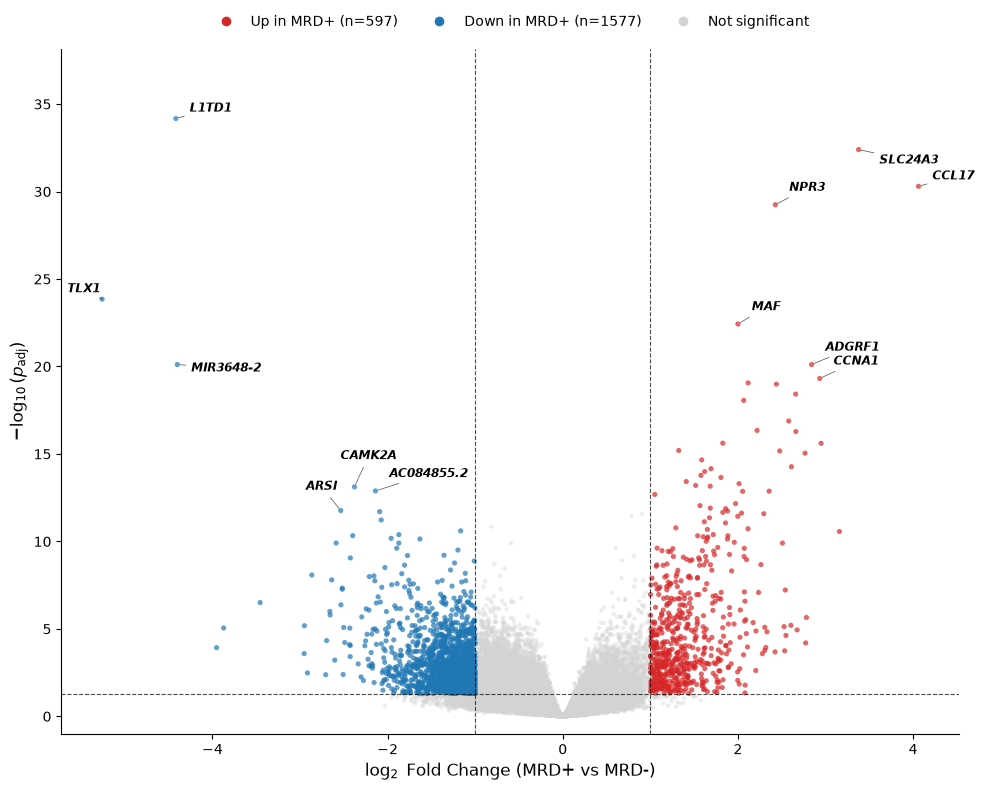

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

plot_df = results_df.copy()
plot_df['neg_log10_padj'] = -np.log10(plot_df['padj'].clip(lower=1e-300))

sig_up = (plot_df['padj'] < 0.05) & (plot_df['log2FoldChange'] >= 1.0)
sig_down = (plot_df['padj'] < 0.05) & (plot_df['log2FoldChange'] <= -1.0)

# Color assignment
colors = np.where(sig_up, '#D62728', np.where(sig_down, '#1F77B4', '#D3D3D3'))

fig, ax = plt.subplots(figsize=(10, 8))

# Plot non-significant points first
ax.scatter(plot_df[~sig_up & ~sig_down]['log2FoldChange'], 
           plot_df[~sig_up & ~sig_down]['neg_log10_padj'],
           c='#D3D3D3', s=10, alpha=0.4, edgecolors='none')

# Plot significant points on top
ax.scatter(plot_df[sig_up | sig_down]['log2FoldChange'], 
           plot_df[sig_up | sig_down]['neg_log10_padj'],
           c=colors[sig_up | sig_down], s=14, alpha=0.7, edgecolors='none')

# Threshold lines
ax.axvline(1.0, linestyle='--', color='black', linewidth=0.8, alpha=0.7)
ax.axvline(-1.0, linestyle='--', color='black', linewidth=0.8, alpha=0.7)
ax.axhline(-np.log10(0.05), linestyle='--', color='black', linewidth=0.8, alpha=0.7)

# Legend at top-center to prevent covering data
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D62728', markersize=8,
           label=f'Up in MRD+ (n={sig_up.sum()})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1F77B4', markersize=8,
           label=f'Down in MRD+ (n={sig_down.sum()})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D3D3D3', markersize=8,
           label='Not significant'),
]
ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 1.01), 
          ncol=3, fontsize=10, frameon=False)

# Custom offsets for crowded labels to avoid overlaps
custom_offsets = {
    'SLC24A3': (15, -10),
    'CCL17': (10, 5),
    'ARSI': (-25, 15),
    'CAMK2A': (-10, 20),
    'AC0684855.2': (15, 15),
    'L1TD1': (10, 5),
    'TLX1': (-25, 5),
    'MIR3648-2': (10, -5)
}

# Select top 6 up and top 6 down genes
top_up = plot_df[sig_up].sort_values('padj').head(6)
top_down = plot_df[sig_down].sort_values('padj').head(6)
top_genes = pd.concat([top_up, top_down])

for gene_name, row in top_genes.iterrows():
    offset = custom_offsets.get(gene_name, (10, 10))
    
    ax.annotate(
        gene_name,
        xy=(row['log2FoldChange'], row['neg_log10_padj']),
        xytext=offset, 
        textcoords='offset points',
        fontsize=8.5, 
        fontstyle='italic',
        fontweight='bold',
        arrowprops=dict(arrowstyle='-', color='black', lw=0.5, alpha=0.7)
    )

# Formatting adjustments
ax.set_xlabel(r'$\log_2$ Fold Change (MRD+ vs MRD-)', fontsize=12)
ax.set_ylabel(r'$-\log_{10}(p_{\mathrm{adj}})$', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Expand y-limits slightly so top labels aren't cut off
y_max = plot_df['neg_log10_padj'].max()
ax.set_ylim(-1, y_max + 4)

plt.tight_layout()
plt.savefig(f"{pycharm_dir}/volcano_MRDpos_vs_MRDneg_labeled.png", dpi=300, bbox_inches='tight')
plt.show()

## 7. Gene Set Enrichment Analysis (GSEA)

In [14]:
import gseapy as gp
import matplotlib.pyplot as plt

# Rank all genes by Wald stat (captures both direction and significance)
ranked = results_df["stat"].sort_values(ascending=False).dropna()
ranked.index.name = None

print(f"Genes in ranked list: {len(ranked)}")
print(ranked.head())
print(ranked.tail())

# Run pre-ranked GSEA against KEGG
gsea_results = gp.prerank(
    rnk=ranked,
    gene_sets="KEGG_2021_Human",
    threads=4,
    min_size=10,
    max_size=500,
    permutation_num=1000,
    outdir=f"{pycharm_dir}/gsea_output",
    seed=42,
    verbose=False
)

gsea_df = gsea_results.res2d.sort_values("NES", ascending=False)
gsea_df.to_csv(f"{pycharm_dir}/GSEA_KEGG_MRD_results.csv", index=False)
print(f"\nPathways tested: {len(gsea_df)}")
print(gsea_df[["Term", "NES", "NOM p-val", "FDR q-val"]].head(20))

2026-09-08 14:07:56,078 [WARNING] Duplicated values found in preranked stats: 0.71% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Genes in ranked list: 57073
SLC24A3    12.793931
CCL17      12.379861
NPR3       12.160439
MAF        10.765413
ADGRF1     10.240315
Name: stat, dtype: float64
AC084855.2    -8.310102
CAMK2A        -8.376800
MIR3648-2    -10.235244
TLX1         -11.079541
L1TD1        -13.160066
Name: stat, dtype: float64

Pathways tested: 311
                                                 Term       NES  NOM p-val  \
0                                            Ribosome  3.706275        0.0   
1                                 Coronavirus disease  3.341833        0.0   
2                                Rheumatoid arthritis  2.348161        0.0   
3                           Oxidative phosphorylation  2.312019        0.0   
4   Viral protein interaction with cytokine and cy...  2.295865        0.0   
5                            Type I diabetes mellitus  2.237766        0.0   
6                                            Lysosome  2.227794        0.0   
7                               Fatty acid elon

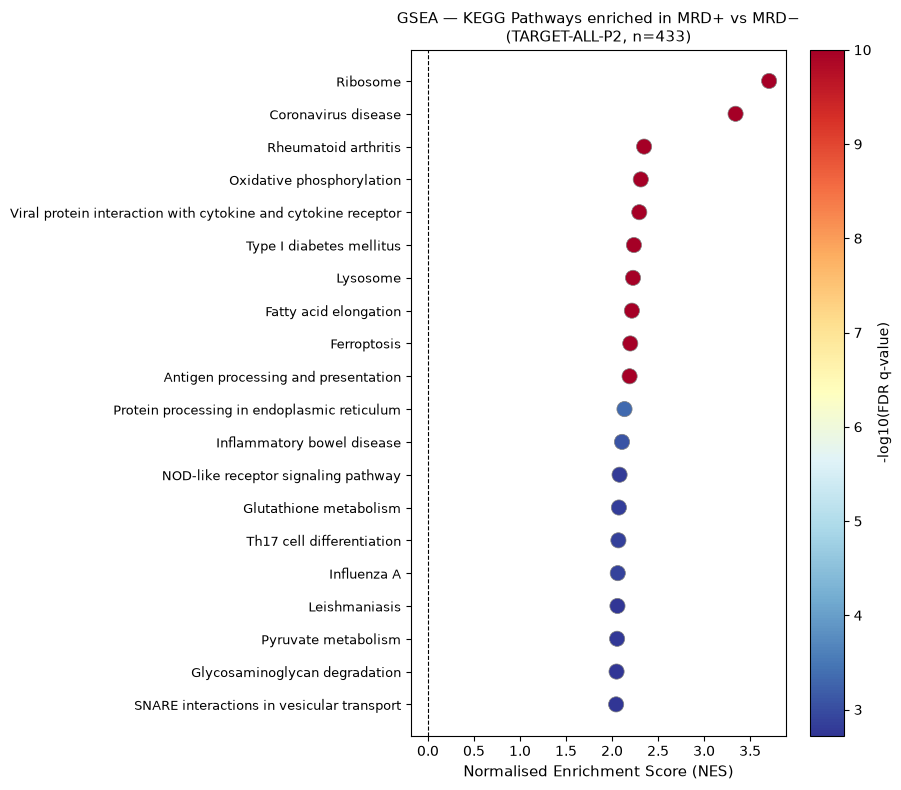

Matched: Ribosome
Matched: Glutathione metabolism
Matched: Lysosome
Matched: TNF signaling pathway
Matched: Ferroptosis


In [15]:
import matplotlib.cm as cm
from gseapy.plot import gseaplot

# Dot plot of top pathways 
gsea_sig = gsea_df[gsea_df["FDR q-val"] < 0.25].copy()
gsea_sig = gsea_sig.sort_values("NES", ascending=True).tail(20)  # top 20 by NES

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    gsea_sig["NES"],
    range(len(gsea_sig)),
    c=-np.log10(gsea_sig["FDR q-val"].clip(lower=1e-10)),
    cmap="RdYlBu_r",
    s=120,
    edgecolors="grey",
    linewidths=0.5
)
ax.set_yticks(range(len(gsea_sig)))
ax.set_yticklabels(gsea_sig["Term"], fontsize=9)
ax.set_xlabel("Normalised Enrichment Score (NES)", fontsize=11)
ax.set_title("GSEA — KEGG Pathways enriched in MRD+ vs MRD−\n(TARGET-ALL-P2, n=433)", fontsize=11)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
plt.colorbar(scatter, label="-log10(FDR q-value)")
plt.tight_layout()
plt.savefig(f"{pycharm_dir}/GSEA_dotplot_MRD.png", dpi=300, bbox_inches="tight")
plt.show()

# Enrichment plots for key pathways 
key_pathways = [
    "Ribosome",
    "Glutathione metabolism",
    "Lysosome",
    "TNF signaling pathway",
    "Ferroptosis",
]

for term in key_pathways:
    exact = [t for t in gsea_results.results.keys() if t.lower() == term.lower()]
    partial = [t for t in gsea_results.results.keys() if term.lower() in t.lower()]
    matches = exact if exact else partial
    
    if not matches:
        print(f"Term not found: {term}")
        continue
    matched_term = matches[0]
    print(f"Matched: {matched_term}")

    gseaplot(
        rank_metric=gsea_results.ranking,
        term=matched_term,
        **gsea_results.results[matched_term],
        ofname=f"{pycharm_dir}/GSEA_enrichment_{matched_term.replace(' ', '_').replace('/', '-')}.png"
    )

2026-09-08 14:08:13,575 [WARNING] Duplicated values found in preranked stats: 0.71% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Pathways tested: 50
                                 Term       NES  NOM p-val  FDR q-val
0           Oxidative Phosphorylation  2.705466        0.0   0.000000
1       TNF-alpha Signaling via NF-kB  2.581630        0.0   0.000000
2                 Allograft Rejection  2.543290        0.0   0.000000
3                      Myc Targets V1  2.422248        0.0   0.000000
4   Epithelial Mesenchymal Transition  2.382141        0.0   0.000000
5           Interferon Gamma Response  2.360977        0.0   0.000000
6     Reactive Oxygen Species Pathway  2.326733        0.0   0.000000
7                IL-2/STAT5 Signaling  2.311348        0.0   0.000000
8             Cholesterol Homeostasis  2.306609        0.0   0.000000
9                        Adipogenesis  2.238062        0.0   0.000000
10                          Apoptosis  2.226897        0.0   0.000000
11                   mTORC1 Signaling  2.214185        0.0   0.000000
12              Inflammatory Response  2.159032        0.0   0.000000


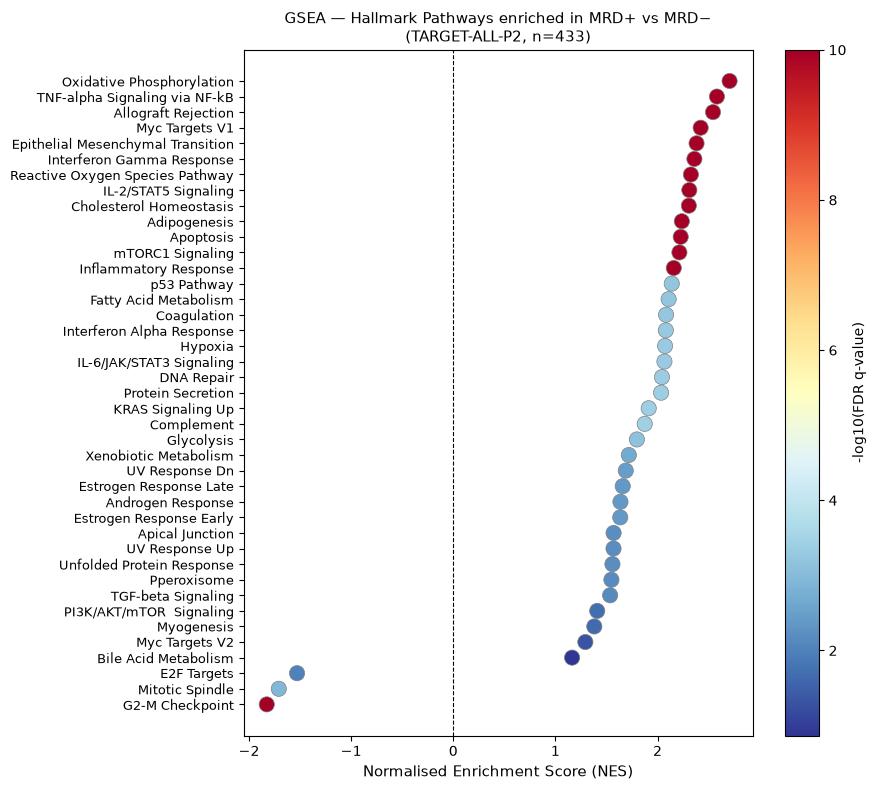

In [16]:
# GSEA against Hallmark gene sets
gsea_hallmark = gp.prerank(
    rnk=ranked,
    gene_sets="MSigDB_Hallmark_2020",
    threads=4,
    min_size=10,
    max_size=500,
    permutation_num=1000,
    outdir=f"{pycharm_dir}/gsea_hallmark_output",
    seed=42,
    verbose=False
)

hallmark_df = gsea_hallmark.res2d.sort_values("NES", ascending=False)
hallmark_df.to_csv(f"{pycharm_dir}/GSEA_Hallmark_MRD_results.csv", index=False)

print(f"Pathways tested: {len(hallmark_df)}")
print(hallmark_df[["Term", "NES", "NOM p-val", "FDR q-val"]].head(20))

# Hallmark dot plot
hallmark_sig = hallmark_df[hallmark_df["FDR q-val"] < 0.25].copy()
hallmark_sig = hallmark_sig.sort_values("NES", ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    hallmark_sig["NES"],
    range(len(hallmark_sig)),
    c=-np.log10(hallmark_sig["FDR q-val"].clip(lower=1e-10)),
    cmap="RdYlBu_r",
    s=120,
    edgecolors="grey",
    linewidths=0.5
)
ax.set_yticks(range(len(hallmark_sig)))
ax.set_yticklabels(hallmark_sig["Term"], fontsize=9)
ax.set_xlabel("Normalised Enrichment Score (NES)", fontsize=11)
ax.set_title("GSEA — Hallmark Pathways enriched in MRD+ vs MRD−\n(TARGET-ALL-P2, n=433)", fontsize=11)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
plt.colorbar(scatter, label="-log10(FDR q-value)")
plt.tight_layout()
plt.savefig(f"{pycharm_dir}/GSEA_dotplot_Hallmark_MRD.png", dpi=300, bbox_inches="tight")
plt.show()


In [17]:
pathways_of_interest = {
    "Ribosome": "Ribosome",
    "Glutathione metabolism": "Glutathione metabolism",
    "Ferroptosis": "Ferroptosis",
    "TNF signaling pathway": "TNF signaling pathway",
    "Lysosome": "Lysosome",
}

for name, term in pathways_of_interest.items():
    genes = gsea_results.results[term]["lead_genes"].split(";")
    sig_genes = results_df.loc[
        results_df.index.isin(genes) & (results_df["padj"] < 0.05) & (results_df["log2FoldChange"].abs() >= 1.0)
    ][["log2FoldChange", "padj"]].sort_values("log2FoldChange", ascending=False)

    print(f"\n=== {name} ===")
    print(f"Total leading edge genes: {len(genes)}")
    print(f"Significantly DE: {len(sig_genes)}")
    print(sig_genes)


=== Ribosome ===
Total leading edge genes: 90
Significantly DE: 0
Empty DataFrame
Columns: [log2FoldChange, padj]
Index: []

=== Glutathione metabolism ===
Total leading edge genes: 24
Significantly DE: 1
           log2FoldChange          padj
gene_name                              
HPGDS            2.766049  9.025440e-16

=== Ferroptosis ===
Total leading edge genes: 27
Significantly DE: 0
Empty DataFrame
Columns: [log2FoldChange, padj]
Index: []

=== TNF signaling pathway ===
Total leading edge genes: 40
Significantly DE: 3
           log2FoldChange          padj
gene_name                              
VEGFC            1.426746  5.700989e-03
CXCL2            1.370974  4.210703e-07
CCL2             1.353621  1.109742e-03

=== Lysosome ===
Total leading edge genes: 48
Significantly DE: 1
           log2FoldChange          padj
gene_name                              
CTSW             1.323442  6.325247e-16


## 8. ALLSorts Molecular Subtyping
### Mapping Subtypes from Gu et al. 2019 on to TARGET-ALL-P2 cohort ###

In [18]:
import pandas as pd
counts = pd.read_csv("/Users/Meralle/PyCharmMiscProject/TARGET_ALL_P2_counts_MRD_samples.csv", index_col=0)
print(counts.shape)
print(counts.index[:5])
print(counts.columns[:5])

(60660, 375)
Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112'], dtype='str', name='gene_name')
Index(['TARGET-10-PATNIA', 'TARGET-10-PARVEI', 'TARGET-10-PARWLP',
       'TARGET-10-PAPPGN', 'TARGET-10-PARMFF'],
      dtype='str')


In [19]:
allsorts_input = counts.T
allsorts_input.to_csv("/Users/Meralle/PyCharmMiscProject/ALLSorts/allsorts_input_counts.csv")
print(allsorts_input.shape)

(375, 60660)


In [20]:
allsorts_results = pd.read_csv("/Users/Meralle/PyCharmMiscProject/ALLSorts/allsorts_output/predictions.csv", index_col=0)
print(allsorts_results.shape)
print(allsorts_results.head())
print(allsorts_results.columns.tolist())

(433, 1)
                       Prediction
TARGET-10-PATNIA     Unclassified
TARGET-10-PARVEI     Unclassified
TARGET-10-PARWLP     Unclassified
TARGET-10-PATEYS     Unclassified
TARGET-10-PAPPGN  PAX5alt,Ph-like
['Prediction']


In [21]:
print(allsorts_results['Prediction'].value_counts(dropna=False))

Prediction
Unclassified                          221
Ph-like                                46
High hyperdiploid                      31
PAX5alt                                25
KMT2A Group                            19
TCF3-PBX1                              16
ETV6-RUNX1                             14
ZNF384 Group                           12
High Sig                                9
PAX5alt,Ph-like                         5
MEF2D                                   5
Ph                                      5
HLF                                     4
iAMP21                                  3
Low hyperdiploid                        3
ETV6-RUNX1-like                         3
DUX4                                    2
PAX5 P80R                               2
NUTM1,High hyperdiploid                 1
Ph Group                                1
Ph Group,ETV6-RUNX1-like                1
Ph Group,PAX5alt                        1
NUTM1                                   1
iAMP21,Low hyperdiploid

#### 1. Clean labels ####

In [22]:
# Take first listed subtype in multi-label calls as primary (most specific)  
allsorts_results['subtype_primary'] = allsorts_results['Prediction'].str.split(',').str[0]

print(allsorts_results['subtype_primary'].value_counts(dropna=False))

subtype_primary
Unclassified         221
Ph-like               46
High hyperdiploid     31
PAX5alt               30
KMT2A Group           19
TCF3-PBX1             17
ETV6-RUNX1            14
ZNF384 Group          12
High Sig               9
MEF2D                  5
Ph                     5
iAMP21                 4
HLF                    4
Ph Group               3
Low hyperdiploid       3
ETV6-RUNX1-like        3
NUTM1                  2
DUX4                   2
PAX5 P80R              2
ETV6-RUNX1 Group       1
Name: count, dtype: int64


#### 2. Merge onto clinical ####

In [23]:
clinical = clinical_df.copy()

clinical = clinical.merge(
    allsorts_results[['subtype_primary']],
    left_on="submitter_id", right_index=True, how="left"
)
clinical = clinical.rename(columns={"subtype_primary": "subtype_allsorts"})

print(clinical["subtype_allsorts"].isna().sum(), "samples with no ALLSorts prediction")
print(clinical[["submitter_id", "mrd_status", "subtype_allsorts"]].head(10))

1154 samples with no ALLSorts prediction
       submitter_id mrd_status subtype_allsorts
0  TARGET-10-PANTTR        NaN              NaN
1  TARGET-10-PANTHU        NaN              NaN
2  TARGET-10-PANKDT    MRD_pos     ZNF384 Group
3  TARGET-10-PANSZD        NaN              NaN
4  TARGET-10-PANSUF        NaN              NaN
5  TARGET-10-PANSUN        NaN              NaN
6  TARGET-10-PANUIN        NaN              NaN
7  TARGET-10-PANPJW    MRD_pos              NaN
8  TARGET-10-PANRDC    MRD_pos     ZNF384 Group
9  TARGET-10-PANUND        NaN              NaN


##### **Confirm merge worked correctly for samples with data** #####

In [24]:
matched = clinical.dropna(subset=["subtype_allsorts"])
print(matched.shape)
print(matched["subtype_allsorts"].value_counts())

(433, 20)
subtype_allsorts
Unclassified         221
Ph-like               46
High hyperdiploid     31
PAX5alt               30
KMT2A Group           19
TCF3-PBX1             17
ETV6-RUNX1            14
ZNF384 Group          12
High Sig               9
MEF2D                  5
Ph                     5
HLF                    4
iAMP21                 4
Ph Group               3
Low hyperdiploid       3
ETV6-RUNX1-like        3
NUTM1                  2
DUX4                   2
PAX5 P80R              2
ETV6-RUNX1 Group       1
Name: count, dtype: int64


#### 3. Add subtype as second annotation column ####

In [25]:
meta = meta.merge(
    allsorts_results[['subtype_primary']].rename(columns={'subtype_primary': 'subtype'}),
    left_index=True, right_index=True, how="left"
)

print(meta.head())
print(meta['subtype'].isna().sum())

                 mrd_status       subtype
sample_id                                
TARGET-10-PATCJJ    MRD_neg     PAX5 P80R
TARGET-10-PARWLP    MRD_neg  Unclassified
TARGET-10-PATBDK    MRD_neg  Unclassified
TARGET-10-PARPNM    MRD_neg         MEF2D
TARGET-10-PASIGB    MRD_neg       Ph-like
0


## 9. Leading-Edge Pathway Heatmap
Visualise the leading-edge genes from the five pathways of interest (Ribosome, Glutathione metabolism, Ferroptosis, TNF signalling, Lysosome), annotated by MRD status and ALLSorts subtype.

Genes appearing in >1 pathway: 1 (assigned to first-listed pathway)


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


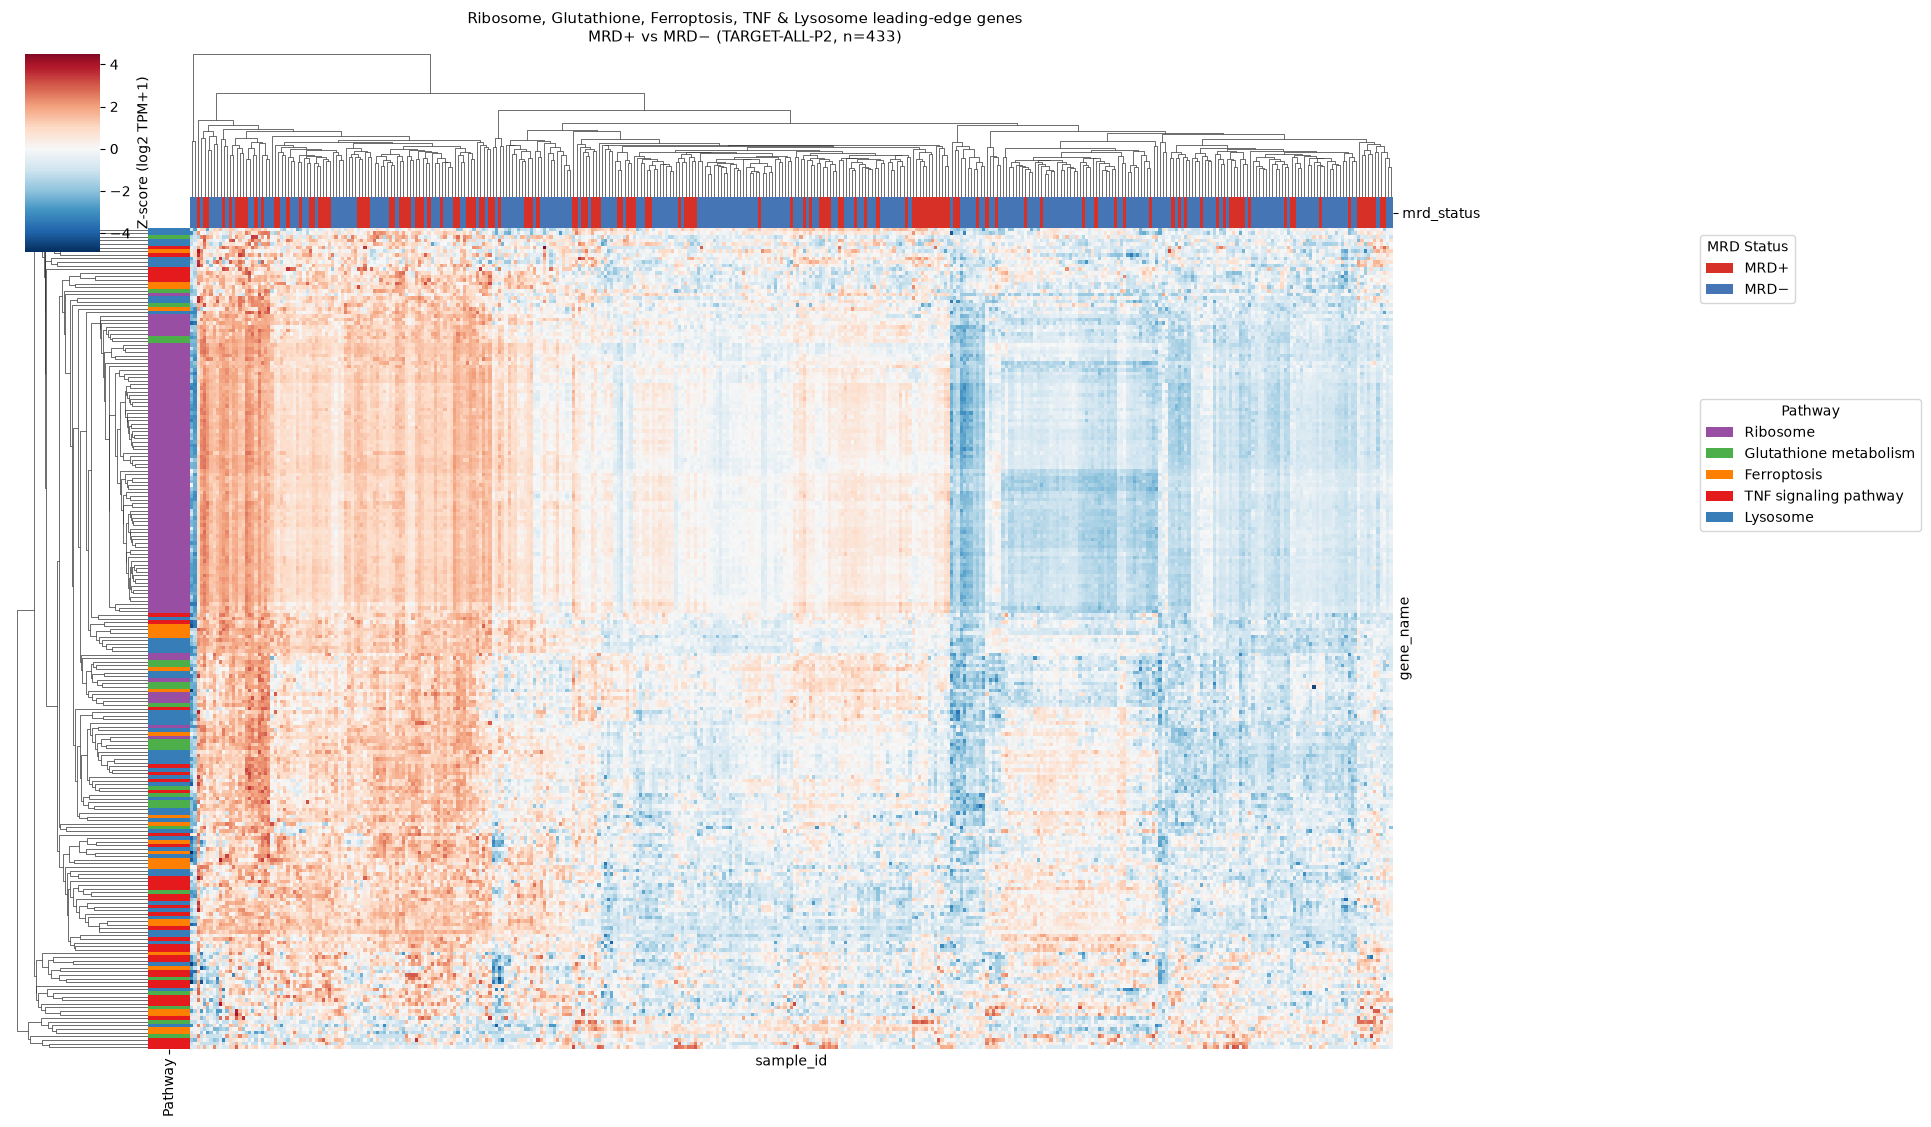

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# --- Leading-edge gene sets per pathway ---
leading_edge_ribosome = gsea_results.results['Ribosome']['lead_genes'].split(';')
leading_edge_glutathione = gsea_results.results['Glutathione metabolism']['lead_genes'].split(';')
leading_edge_ferroptosis = gsea_results.results['Ferroptosis']['lead_genes'].split(';')
leading_edge_tnf = gsea_results.results['TNF signaling pathway']['lead_genes'].split(';')
leading_edge_lysosome = gsea_results.results['Lysosome']['lead_genes'].split(';')

heatmap_genes = list(set(
    leading_edge_ribosome + leading_edge_glutathione + leading_edge_ferroptosis +
    leading_edge_tnf + leading_edge_lysosome
))

# --- Gene -> pathway mapping for row colors ---
pathway_sets = {
    "Ribosome": set(leading_edge_ribosome),
    "Glutathione metabolism": set(leading_edge_glutathione),
    "Ferroptosis": set(leading_edge_ferroptosis),
    "TNF signaling pathway": set(leading_edge_tnf),
    "Lysosome": set(leading_edge_lysosome),
}
pathway_colors = {
    "Ribosome": "#984ea3",
    "Glutathione metabolism": "#4daf4a",
    "Ferroptosis": "#ff7f00",
    "TNF signaling pathway": "#e41a1c",
    "Lysosome": "#377eb8",
}

gene_pathway = {}
overlap_count = 0
for gene in heatmap_genes:
    membership = [p for p, genes in pathway_sets.items() if gene in genes]
    if len(membership) > 1:
        overlap_count += 1
    gene_pathway[gene] = membership[0] if membership else "Unknown"

print(f"Genes appearing in >1 pathway: {overlap_count} (assigned to first-listed pathway)")

# --- Expression matrix ---
expr_sub = expr_mrd.loc[expr_mrd.index.isin(heatmap_genes), meta.index]
expr_log = np.log2(expr_sub + 1)
expr_z = expr_log.subtract(expr_log.mean(axis=1), axis=0).divide(expr_log.std(axis=1), axis=0)

# --- Row colors (pathway) ---
row_pathway_series = pd.Series({g: gene_pathway[g] for g in expr_z.index}, name="Pathway")
row_colors = row_pathway_series.map(pathway_colors)

# --- Column colors (MRD status) ---
mrd_colors = meta["mrd_status"].map({"MRD_pos": "#d73027", "MRD_neg": "#4575b4"})

# --- Sort samples: all MRD+ block, then all MRD- block ---
sample_order = meta[meta["mrd_status"] == "MRD_pos"].index.tolist() + \
               meta[meta["mrd_status"] == "MRD_neg"].index.tolist()

expr_z_sorted = expr_z[sample_order]
mrd_colors_sorted = mrd_colors[sample_order]

# --- Plot ---
g_plot = sns.clustermap(
    expr_z,  # unsorted — don't reindex to sample_order
    col_colors=mrd_colors,  # also unsorted, matching expr_z's column order
    row_colors=row_colors,
    cmap="RdBu_r",
    center=0,
    figsize=(15, 11),
    xticklabels=False,
    yticklabels=False,
    dendrogram_ratio=(0.1, 0.15),
    cbar_kws={"label": "Z-score (log2 TPM+1)"},
    col_cluster=True,   # was False
    row_cluster=True
)


g_plot.fig.suptitle(
    "Ribosome, Glutathione, Ferroptosis, TNF & Lysosome leading-edge genes\nMRD+ vs MRD− (TARGET-ALL-P2, n=433)",
    y=1.02, fontsize=11
)

mrd_legend = [Patch(facecolor="#d73027", label="MRD+"), Patch(facecolor="#4575b4", label="MRD−")]
pathway_legend = [Patch(facecolor=c, label=p) for p, c in pathway_colors.items()]

leg1 = g_plot.ax_heatmap.legend(
    handles=mrd_legend, loc="upper left", bbox_to_anchor=(1.25, 1.0),
    frameon=True, title="MRD Status"
)
g_plot.ax_heatmap.add_artist(leg1)
g_plot.ax_heatmap.legend(
    handles=pathway_legend, loc="upper left", bbox_to_anchor=(1.25, 0.8),
    frameon=True, title="Pathway"
)

plt.savefig(f"{pycharm_dir}/Heatmap_5pathways_annotated_final.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
meta = meta.drop(columns=[c for c in ["subtype", "subtype_primary"] if c in meta.columns])
meta = meta.join(allsorts_results["subtype_primary"], how="left")
meta = meta.rename(columns={"subtype_primary": "subtype"})
meta["subtype"] = meta["subtype"].fillna("Unclassified")

print(meta.columns.tolist())
print(meta["subtype"].value_counts())

['mrd_status', 'subtype']
subtype
Unclassified         194
Ph-like               40
High hyperdiploid     30
PAX5alt               29
KMT2A Group           14
TCF3-PBX1             13
ZNF384 Group          10
ETV6-RUNX1             9
High Sig               7
MEF2D                  5
Ph                     5
HLF                    3
ETV6-RUNX1-like        3
Low hyperdiploid       3
PAX5 P80R              2
iAMP21                 2
Ph Group               2
NUTM1                  2
ETV6-RUNX1 Group       1
DUX4                   1
Name: count, dtype: int64


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


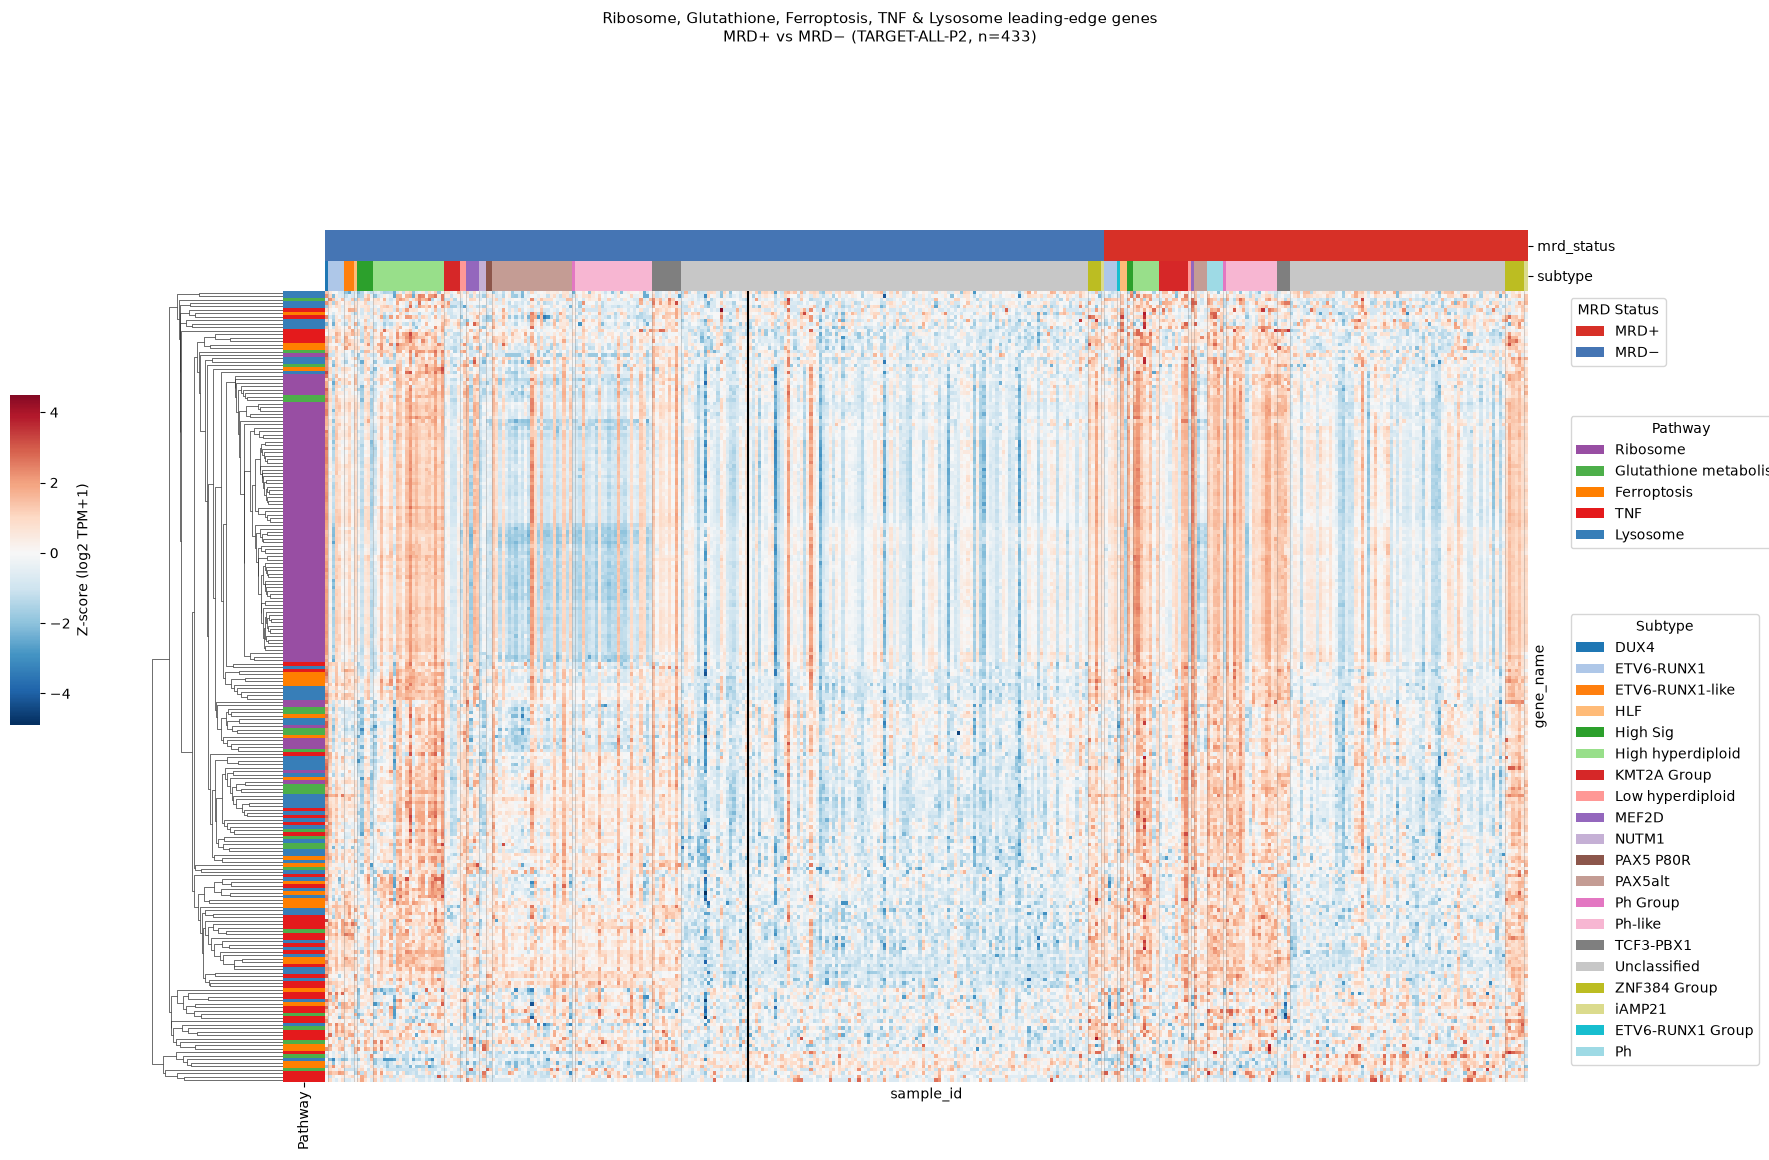

In [28]:
# --- Sort samples: MRD block, then subtype within each block ---
meta_sorted = meta.sort_values(by=["mrd_status", "subtype"])
sample_order = meta_sorted.index.tolist()

expr_z_sorted = expr_z[sample_order]

# --- Column color bars: MRD status + subtype ---
mrd_colors_sorted = meta_sorted["mrd_status"].map({"MRD_pos": "#d73027", "MRD_neg": "#4575b4"})

subtypes = meta_sorted["subtype"].unique()
subtype_palette = sns.color_palette("tab20", len(subtypes))
subtype_color_map = dict(zip(subtypes, subtype_palette))
subtype_colors_sorted = meta_sorted["subtype"].map(subtype_color_map)

col_colors_df = pd.DataFrame({
    "mrd_status": mrd_colors_sorted,
    "subtype": subtype_colors_sorted
})

# --- Plot ---
g_plot = sns.clustermap(
    expr_z_sorted,
    col_colors=col_colors_df,
    row_colors=row_colors,
    cmap="RdBu_r",
    center=0,
    figsize=(15, 11),
    xticklabels=False,
    yticklabels=False,
    dendrogram_ratio=(0.1, 0.15),
    cbar_kws={"label": "Z-score (log2 TPM+1)"},
    cbar_pos=(-0.08, 0.4, 0.02, 0.3),
    col_cluster=False,   # fixed order, not clustering
    row_cluster=True
)

# vertical line at MRD+/MRD- boundary
n_pos = (meta_sorted["mrd_status"] == "MRD_pos").sum()
g_plot.ax_heatmap.axvline(x=n_pos, color='black', linewidth=1.5)

# vertical lines at each subtype boundary within blocks
boundaries = meta_sorted.reset_index().groupby(
    (meta_sorted.reset_index()["mrd_status"] != meta_sorted.reset_index()["mrd_status"].shift()).cumsum()
    .astype(str) + meta_sorted.reset_index()["subtype"].astype(str)
).apply(lambda x: x.index[-1] + 1)
for b in boundaries[:-1]:
    g_plot.ax_heatmap.axvline(x=b, color='grey', linewidth=0.4, alpha=0.6)

g_plot.fig.suptitle(
    "Ribosome, Glutathione, Ferroptosis, TNF & Lysosome leading-edge genes\nMRD+ vs MRD− (TARGET-ALL-P2, n=433)",
    y=1.05, fontsize=11
)

mrd_legend = [Patch(facecolor="#d73027", label="MRD+"), Patch(facecolor="#4575b4", label="MRD−")]
pathway_legend = [Patch(facecolor=c, label=p.replace(" signaling pathway", "")) for p, c in pathway_colors.items()]
subtype_legend = [Patch(facecolor=c, label=s) for s, c in subtype_color_map.items()]

leg1 = g_plot.ax_heatmap.legend(handles=mrd_legend, loc="upper left", bbox_to_anchor=(1.03, 1.0), frameon=True, title="MRD Status")
g_plot.ax_heatmap.add_artist(leg1)
leg2 = g_plot.ax_heatmap.legend(handles=pathway_legend, loc="upper left", bbox_to_anchor=(1.03, 0.85), frameon=True, title="Pathway")
g_plot.ax_heatmap.add_artist(leg2)
g_plot.ax_heatmap.legend(handles=subtype_legend, loc="upper left", bbox_to_anchor=(1.03, 0.6), frameon=True, title="Subtype")

plt.savefig(f"{pycharm_dir}/Heatmap_5pathways_leadingedge_mrd_subtype_grouped.png", dpi=300, bbox_inches="tight")
plt.show()

**Robustness checks (not shown as code):** the MRD-associated leading-edge signal above was checked against a sequencing-depth batch effect (see Section 10) and was not driven by library size. Restricting to the high-depth batch and grouping by ALLSorts subtype, the same pattern held, and the Ph-like/PAX5alt subtypes stood out with a higher mean leading-edge z-score than the rest of the cohort (Mann–Whitney U test).

# 10. Log-CPM Normalisation, Exploratory UMAP & Sequencing-Depth Batch Check
Normalise the raw counts to log2(CPM+1) for use in UMAP and pathway-score analyses below. Note: UMAP in this section is not correct. Corrected version in Section 17.

In [29]:
# Normalise raw counts before UMAP
cpm = expr_mrd.div(expr_mrd.sum(axis=0), axis=1) * 1e6
log_cpm = np.log2(cpm + 1)

print(log_cpm.shape)
print(log_cpm.iloc[:5, :3])

(60660, 375)
           TARGET-10-PATNIA  TARGET-10-PARVEI  TARGET-10-PARWLP
gene_name                                                      
TSPAN6             0.058953          3.280130          0.000000
TNMD               0.000000          0.084768          0.000000
DPM1               5.293002          5.574662          5.070449
SCYL3              3.503855          4.300103          4.449881
C1orf112           5.109967          4.427286          5.149172


In [30]:
# Collapse duplicated gene symbols 
log_cpm_dedup = log_cpm.groupby(level=0).sum()
print(log_cpm_dedup.shape)
print(log_cpm_dedup.index.duplicated().sum())

(59427, 375)
0


#### 4. UMAP on Top Variable Genes ####

In [31]:
from umap import UMAP

# Select top 2000 most variable genes
gene_var = log_cpm_dedup.var(axis=1)
top_genes = gene_var.sort_values(ascending=False).head(2000).index

umap_input = log_cpm_dedup.loc[top_genes].T
print(umap_input.shape)

/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(375, 2000)


In [32]:
reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(umap_input)

umap_df = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"], index=umap_input.index)
umap_df = umap_df.merge(meta, left_index=True, right_index=True, how="left")

print(umap_df.head())

/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


                      UMAP1      UMAP2 mrd_status       subtype
TARGET-10-PATNIA -10.088554   7.324925    MRD_neg  Unclassified
TARGET-10-PARVEI -11.233811   3.768508    MRD_neg  Unclassified
TARGET-10-PARWLP -10.848457   3.594245    MRD_neg  Unclassified
TARGET-10-PAPPGN   7.737907  15.467831    MRD_neg       PAX5alt
TARGET-10-PARMFF -11.179324   4.368011    MRD_neg  Unclassified


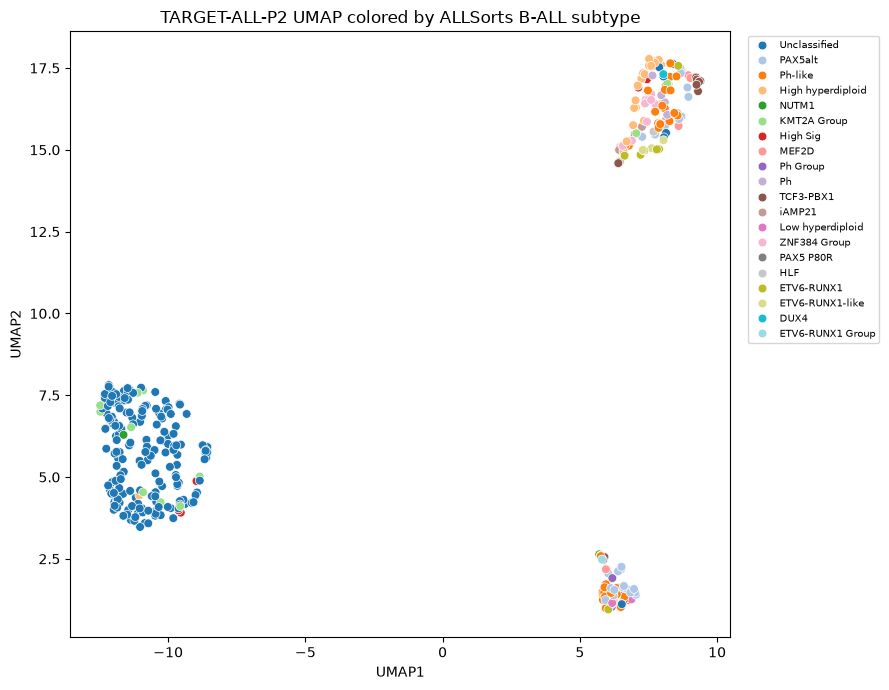

In [33]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=umap_df, x="UMAP1", y="UMAP2",
    hue="subtype", palette="tab20", s=40, ax=ax
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.title("TARGET-ALL-P2 UMAP colored by ALLSorts B-ALL subtype")
plt.tight_layout()
plt.show()

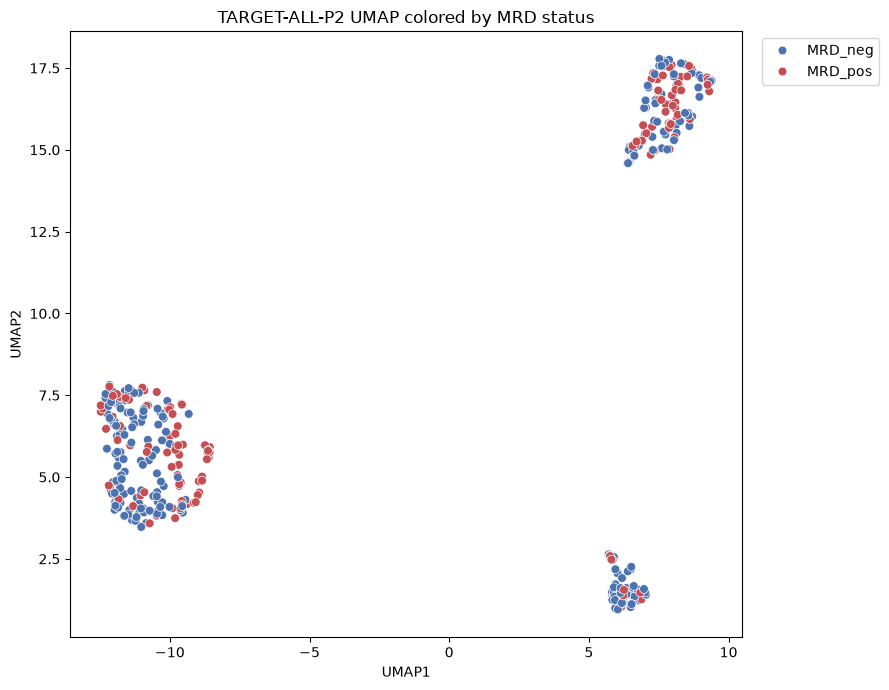

In [34]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=umap_df, x="UMAP1", y="UMAP2",
    hue="mrd_status", palette={"MRD_neg": "#4C72B0", "MRD_pos": "#C44E52"},
    s=40, ax=ax
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("TARGET-ALL-P2 UMAP colored by MRD status")
plt.tight_layout()
plt.show()

A first pass of UMAP (above) showed samples splitting into two broad clusters that lined up with sequencing depth rather than biology — a batch effect that needed to be corrected before UMAP could be trusted for subtyping (see Section 17 for the depth-corrected version). The depth split identified here is also used below to define a *high-depth batch* for sensitivity checks.

In [35]:
# High-sequencing-depth batch, identified from the UMAP1 split above.
# Used throughout as a sensitivity/robustness subset to check that associations
# with MRD status are not driven by the sequencing-depth batch effect.
lib_size = expr_mrd.sum(axis=0)  # total counts per sample
hd_samples = list(umap_df.index[umap_df['UMAP1'] > -5])
print(f"High-depth batch: {len(hd_samples)} / {len(umap_df)} samples")

High-depth batch: 173 / 375 samples


## 11. TPMT/NUDT15 Expression vs MRD Status and Subtype
Build a per-sample analysis table combining TPMT/NUDT15 expression, MRD status, subtype and the leading-edge pathway score, then test associations.

In [36]:
tpmt_nudt15_expr = log_cpm_dedup.loc[log_cpm_dedup.index.isin(["TPMT", "NUDT15"])]
print(tpmt_nudt15_expr.shape)
print(tpmt_nudt15_expr)

(2, 375)
           TARGET-10-PATNIA  TARGET-10-PARVEI  TARGET-10-PARWLP  \
gene_name                                                         
NUDT15             3.947808          3.457501          4.565383   
TPMT               3.482479          3.496702          1.528308   

           TARGET-10-PAPPGN  TARGET-10-PARMFF  TARGET-10-PASLMB  \
gene_name                                                         
NUDT15             3.129309          4.655984          3.509714   
TPMT               1.873931          3.720825          1.692177   

           TARGET-10-PARXMV  TARGET-10-PAPLDM  TARGET-10-PAPHGD  \
gene_name                                                         
NUDT15             4.833987          3.425264          4.219368   
TPMT               3.192228          2.045847          2.719204   

           TARGET-10-PANYEJ  ...  TARGET-10-PASSSR  TARGET-10-PARSNX  \
gene_name                    ...                                       
NUDT15             2.908190  ...        

In [37]:
#build analysis dataframe 
tpmt_nudt15_t = tpmt_nudt15_expr.T
tpmt_nudt15_t.columns = ["NUDT15_expr", "TPMT_expr"]

analysis_df = meta.copy()
analysis_df = analysis_df.merge(tpmt_nudt15_t, left_index=True, right_index=True, how="left")
analysis_df["leading_edge_score"] = expr_z.mean(axis=0).reindex(analysis_df.index)

print(analysis_df[["mrd_status", "subtype", "TPMT_expr", "NUDT15_expr", "leading_edge_score"]].head())
print(analysis_df.shape)

                 mrd_status       subtype  TPMT_expr  NUDT15_expr  \
sample_id                                                           
TARGET-10-PATCJJ    MRD_neg     PAX5 P80R   1.783048     2.931929   
TARGET-10-PARWLP    MRD_neg  Unclassified   1.528308     4.565383   
TARGET-10-PATBDK    MRD_neg  Unclassified   3.954438     3.996549   
TARGET-10-PARPNM    MRD_neg         MEF2D   3.606000     3.721426   
TARGET-10-PASIGB    MRD_neg       Ph-like   3.117310     3.136450   

                  leading_edge_score  
sample_id                             
TARGET-10-PATCJJ           -0.135525  
TARGET-10-PARWLP           -1.020053  
TARGET-10-PATBDK            0.173017  
TARGET-10-PARPNM            0.876362  
TARGET-10-PASIGB           -0.185881  
(375, 5)


In [38]:
# Correlation between TPMT/NUDT15 experssion and leading-edge glutathione/ferroptosis score
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu

for gene in ["TPMT_expr", "NUDT15_expr"]:
    rho, pval = spearmanr(analysis_df[gene], analysis_df["leading_edge_score"])
    print(f"{gene} vs leading-edge score: rho={rho:.3f}, p={pval:.4f}")

TPMT_expr vs leading-edge score: rho=0.230, p=0.0000
NUDT15_expr vs leading-edge score: rho=-0.049, p=0.3464


In [39]:
# TPMT/NUDT15 expression by MRD status directly 
for gene in ["TPMT_expr", "NUDT15_expr"]:
    pos_vals = analysis_df.loc[analysis_df["mrd_status"] == "MRD_pos", gene]
    neg_vals = analysis_df.loc[analysis_df["mrd_status"] == "MRD_neg", gene]
    stat, pval = mannwhitneyu(pos_vals, neg_vals, alternative="two-sided")
    print(f"{gene}: MRD+ mean={pos_vals.mean():.3f}, MRD- mean={neg_vals.mean():.3f}, p={pval:.4f}")

TPMT_expr: MRD+ mean=3.065, MRD- mean=2.677, p=0.0001
NUDT15_expr: MRD+ mean=3.897, MRD- mean=3.900, p=0.8964


/var/folders/v_/j7694ws56vlb4hc0yb3b8xrr0000gn/T/ipykernel_54280/2294557687.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["MRD−", "MRD+"])
/var/folders/v_/j7694ws56vlb4hc0yb3b8xrr0000gn/T/ipykernel_54280/2294557687.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["MRD−", "MRD+"])


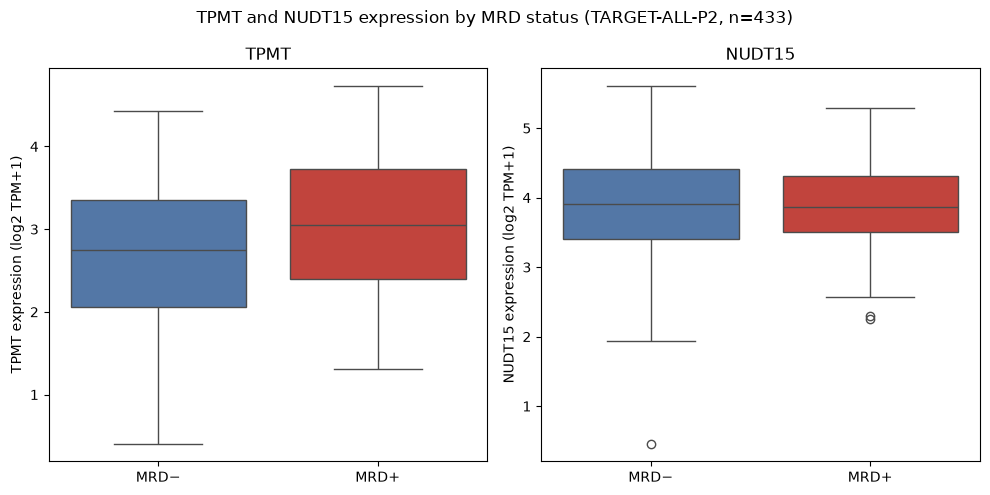

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, gene in zip(axes, ["TPMT_expr", "NUDT15_expr"]):
    sns.boxplot(
        data=analysis_df,
        x="mrd_status",
        y=gene,
        order=["MRD_neg", "MRD_pos"],
        palette={"MRD_neg": "#4575b4", "MRD_pos": "#d73027"},
        ax=ax
    )
    ax.set_xticklabels(["MRD−", "MRD+"])
    ax.set_xlabel("")
    ax.set_ylabel(f"{gene.replace('_expr','')} expression (log2 TPM+1)")
    ax.set_title(gene.replace("_expr", ""))

plt.suptitle("TPMT and NUDT15 expression by MRD status (TARGET-ALL-P2, n=433)")
plt.tight_layout()
plt.savefig(f"{pycharm_dir}/Boxplot_TPMT_NUDT15_by_MRD.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
# check TPMT expression by subtype, restricted to depth-matched batch to avoid same batch confound
analysis_df_hd = analysis_df.loc[analysis_df.index.intersection(hd_samples)]

from scipy.stats import kruskal

groups = [g["TPMT_expr"].values for _, g in analysis_df_hd.groupby("subtype") if len(g) >= 5]
stat, pval = kruskal(*groups)
print(f"Kruskal-Wallis TPMT_expr across subtypes (n>=5 each): p={pval:.4f}")

# Re-test MRD association within depth-matched batch only, as a robustness check
pos_hd = analysis_df_hd.loc[analysis_df_hd["mrd_status"] == "MRD_pos", "TPMT_expr"]
neg_hd = analysis_df_hd.loc[analysis_df_hd["mrd_status"] == "MRD_neg", "TPMT_expr"]
stat2, pval2 = mannwhitneyu(pos_hd, neg_hd, alternative="two-sided")
print(f"TPMT MRD+ vs MRD- (depth-matched only): MRD+ mean={pos_hd.mean():.3f}, MRD- mean={neg_hd.mean():.3f}, p={pval2:.4f}")

Kruskal-Wallis TPMT_expr across subtypes (n>=5 each): p=0.0000
TPMT MRD+ vs MRD- (depth-matched only): MRD+ mean=2.776, MRD- mean=2.334, p=0.0027


1. TPMT expression does vary significantly by subtype (p<0.0001). So subtype is a real confound that needs to be accounted for, not ignored.
2. TPMT-MRD association survives even in the depth-matched subtype-reliable subset (p=0.0027). MRD+ higher than MRD-.

Need to check if TPMT's MRD effect holds wihtin each subtype using multivariate analysis. 

In [42]:
import statsmodels.formula.api as smf

model_df = analysis_df_hd.copy()
model_df = model_df[model_df["subtype"] != "Unclassified"]  # exclude unreliable calls

model = smf.ols("TPMT_expr ~ mrd_status + C(subtype)", data=model_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              TPMT_expr   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     4.127
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           3.92e-07
Time:                        14:08:42   Log-Likelihood:                -175.54
No. Observations:                 165   AIC:                             391.1
Df Residuals:                     145   BIC:                             453.2
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

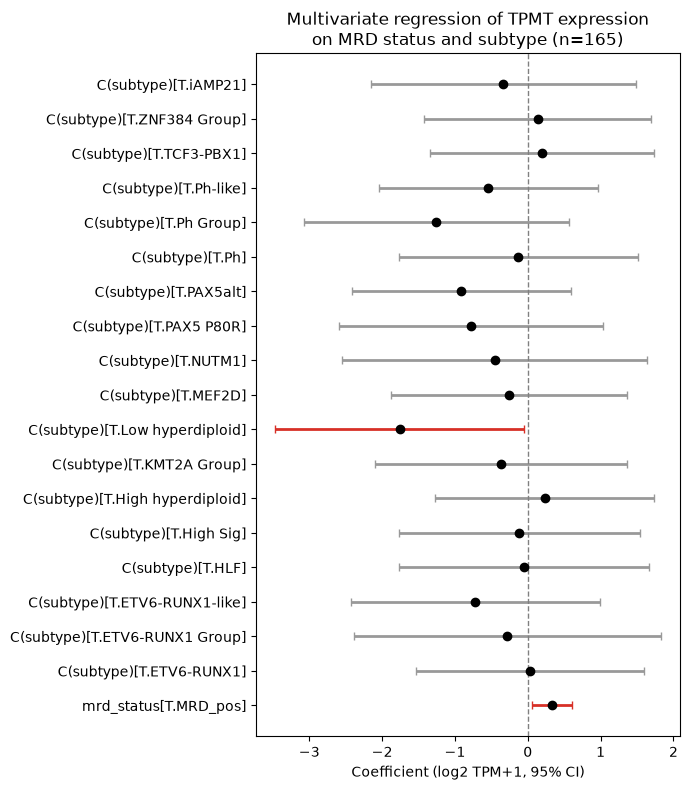

In [43]:
import numpy as np

model_results_df = pd.DataFrame({
    "coef": model.params,
    "ci_low": model.conf_int()[0],
    "ci_high": model.conf_int()[1],
    "pval": model.pvalues,
}).drop("Intercept", errors="ignore")

coef = model_results_df["coef"].to_numpy()
ci_low = model_results_df["ci_low"].to_numpy()
ci_high = model_results_df["ci_high"].to_numpy()
labels = model_results_df.index.to_numpy()
colors = model_results_df["pval"].apply(lambda p: "#d73027" if p < 0.05 else "#999999").to_numpy()

fig, ax = plt.subplots(figsize=(7, 8))

for i, (c, lo, hi, col) in enumerate(zip(coef, ci_low, ci_high, colors)):
    ax.errorbar(c, i, xerr=[[c - lo], [hi - c]], fmt="o", color="black", ecolor=col, elinewidth=2, capsize=3)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.axvline(x=0, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Coefficient (log2 TPM+1, 95% CI)")
ax.set_title("Multivariate regression of TPMT expression\non MRD status and subtype (n=165)")

plt.tight_layout()
plt.savefig(f"{pycharm_dir}/Forestplot_TPMT_regression.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ribosome Biogenesis/Translation and TNF Signalling Exploration ####

In [44]:
print(gsea_sig[gsea_sig['Term'].str.contains('Ribosome', case=False, na=False)][['Term', 'NES', 'FDR q-val', 'Lead_genes']])
print()
print(hallmark_sig[hallmark_sig['Term'].str.contains('TNF|tnfa', case=False, na=False)][['Term', 'NES', 'FDR q-val', 'Lead_genes']])

       Term       NES  FDR q-val  \
0  Ribosome  3.706275        0.0   

                                          Lead_genes  
0  RPL22;RPS6;RPL14;RPL13;RPS28;RPS18;RPS8;RPL5;R...  

                            Term      NES  FDR q-val  \
1  TNF-alpha Signaling via NF-kB  2.58163        0.0   

                                          Lead_genes  
1  DUSP5;ID2;IL18;CXCL2;PLAU;MAP3K8;BHLHE40;RNF19...  


In [45]:
ribosome_genes = gsea_sig[gsea_sig['Term']=='Ribosome']['Lead_genes'].values[0].split(';')
tnf_genes = hallmark_sig[hallmark_sig['Term']=='TNF-alpha Signaling via NF-kB']['Lead_genes'].values[0].split(';')

print(f"Ribosome leading-edge genes: {len(ribosome_genes)}")
print(ribosome_genes[:15])
print()
print(f"TNF-alpha leading-edge genes: {len(tnf_genes)}")
print(tnf_genes[:15])

Ribosome leading-edge genes: 90
['RPL22', 'RPS6', 'RPL14', 'RPL13', 'RPS28', 'RPS18', 'RPS8', 'RPL5', 'RPL37A', 'RPS23', 'RPL15', 'RPL32', 'RPS24', 'RPL7', 'RPS20']

TNF-alpha leading-edge genes: 81
['DUSP5', 'ID2', 'IL18', 'CXCL2', 'PLAU', 'MAP3K8', 'BHLHE40', 'RNF19B', 'CLCF1', 'GADD45A', 'JUNB', 'IER5', 'PHLDA1', 'FOSL2', 'LITAF']


In [46]:
def compute_pathway_score(gene_list, log_cpm_data):
    present = [g for g in gene_list if g in log_cpm_data.index]
    sub = log_cpm_data.loc[present]
    z = sub.subtract(sub.mean(axis=1), axis=0).divide(sub.std(axis=1), axis=0)
    return z.mean(axis=0), len(present)

ribosome_score, n_ribo = compute_pathway_score(ribosome_genes, log_cpm_dedup)
tnf_score, n_tnf = compute_pathway_score(tnf_genes, log_cpm_dedup)

glutathione_genes = gsea_results.results['Glutathione metabolism']['lead_genes'].split(';')
glutathione_score, n_gluta = compute_pathway_score(glutathione_genes, log_cpm_dedup)

ferroptosis_genes = gsea_results.results['Ferroptosis']['lead_genes'].split(';')
ferroptosis_score, n_ferro = compute_pathway_score(ferroptosis_genes, log_cpm_dedup)

lysosome_genes = gsea_results.results['Lysosome']['lead_genes'].split(';')
lysosome_score, n_lyso = compute_pathway_score(lysosome_genes, log_cpm_dedup)

print(f"Ribosome: {n_ribo} genes | TNF: {n_tnf} genes | Glutathione: {n_gluta} genes | "
      f"Ferroptosis: {n_ferro} genes | Lysosome: {n_lyso} genes")

Ribosome: 90 genes | TNF: 81 genes | Glutathione: 24 genes | Ferroptosis: 27 genes | Lysosome: 48 genes


In [47]:
analysis_df1 = analysis_df.copy()

In [48]:
analysis_df1['ribosome_score'] = ribosome_score.reindex(analysis_df1.index)
analysis_df1['tnf_score'] = tnf_score.reindex(analysis_df1.index)
analysis_df1['glutathione_score'] = glutathione_score.reindex(analysis_df1.index)
analysis_df1['ferroptosis_score'] = ferroptosis_score.reindex(analysis_df1.index)
analysis_df1['lysosome_score'] = lysosome_score.reindex(analysis_df1.index)

In [49]:
analysis_df1['lib_size'] = lib_size.reindex(analysis_df1.index)

score_cols = ['ribosome_score', 'tnf_score', 'glutathione_score', 'ferroptosis_score', 'lysosome_score']
for col in score_cols:
    rho, pval = spearmanr(analysis_df1['lib_size'], analysis_df1[col])
    print(f"{col} vs library size: rho={rho:.3f}, p={pval:.4f}")

ribosome_score vs library size: rho=0.267, p=0.0000
tnf_score vs library size: rho=0.270, p=0.0000
glutathione_score vs library size: rho=0.195, p=0.0001
ferroptosis_score vs library size: rho=-0.148, p=0.0040
lysosome_score vs library size: rho=0.236, p=0.0000


In [50]:
for col in score_cols:
    pos_vals = analysis_df1.loc[analysis_df1['mrd_status']=='MRD_pos', col]
    neg_vals = analysis_df1.loc[analysis_df1['mrd_status']=='MRD_neg', col]
    stat, pval = mannwhitneyu(pos_vals, neg_vals, alternative='two-sided')
    print(f"{col}: MRD+ mean={pos_vals.mean():.3f}, MRD- mean={neg_vals.mean():.3f}, p={pval:.4f}")

ribosome_score: MRD+ mean=0.254, MRD- mean=-0.138, p=0.0001
tnf_score: MRD+ mean=0.118, MRD- mean=-0.064, p=0.0003
glutathione_score: MRD+ mean=0.181, MRD- mean=-0.099, p=0.0000
ferroptosis_score: MRD+ mean=0.084, MRD- mean=-0.046, p=0.0002
lysosome_score: MRD+ mean=0.168, MRD- mean=-0.091, p=0.0000


In [51]:
rho1, p1 = spearmanr(analysis_df1['ribosome_score'], analysis_df1['leading_edge_score'])
rho2, p2 = spearmanr(analysis_df1['tnf_score'], analysis_df1['leading_edge_score'])
rho3, p3 = spearmanr(analysis_df1['ribosome_score'], analysis_df1['tnf_score'])
print(f"Ribosome vs leading-edge: rho={rho1:.3f}, p={p1:.4f}")
print(f"TNF vs leading-edge: rho={rho2:.3f}, p={p2:.4f}")
print(f"Ribosome vs TNF: rho={rho3:.3f}, p={p3:.4f}")

Ribosome vs leading-edge: rho=0.677, p=0.0000
TNF vs leading-edge: rho=0.254, p=0.0000
Ribosome vs TNF: rho=-0.025, p=0.6286


- Ribosome and TNF are independent of each other. Two separate MRD-associated programs
- Both correlate moderately with glutathione/ferroptosis leading-edge score. 

In [52]:
model_df3 = analysis_df1.copy()
model_df3['mrd_binary'] = (model_df3['mrd_status'] == 'MRD_pos').astype(int)

logit_model = smf.logit(
    "mrd_binary ~ ribosome_score + tnf_score + glutathione_score + ferroptosis_score + lysosome_score",
    data=model_df3
).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.585509
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             mrd_binary   No. Observations:                  375
Model:                          Logit   Df Residuals:                      369
Method:                           MLE   Df Model:                            5
Date:                Tue, 08 Sep 2026   Pseudo R-squ.:                 0.09738
Time:                        14:08:43   Log-Likelihood:                -219.57
converged:                       True   LL-Null:                       -243.25
Covariance Type:            nonrobust   LLR p-value:                 4.764e-09
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.7105      0.119     -5.978      0.000      -0.943      -0.478
ribosome

In [53]:
for score_col in ['ribosome_score', 'tnf_score']:
    rho, pval = spearmanr(analysis_df1['TPMT_expr'], analysis_df1[score_col])
    print(f"TPMT vs {score_col}: rho={rho:.3f}, p={pval:.4f}")

rho_nudt, p_nudt = spearmanr(analysis_df1['NUDT15_expr'], analysis_df1['tnf_score'])
print(f"NUDT15 vs tnf_score: rho={rho_nudt:.3f}, p={p_nudt:.4f}")

TPMT vs ribosome_score: rho=0.361, p=0.0000
TPMT vs tnf_score: rho=-0.030, p=0.5641
NUDT15 vs tnf_score: rho=-0.097, p=0.0605


#### GO Enrichment ####

In [54]:
print(ranked.shape)
print(ranked.head())
print(ranked.index.name)

(57073,)
SLC24A3    12.793931
CCL17      12.379861
NPR3       12.160439
MAF        10.765413
ADGRF1     10.240315
Name: stat, dtype: float64
None


In [55]:
import gseapy as gp

gsea_go_bp = gp.prerank(
    rnk=ranked,
    gene_sets="GO_Biological_Process_2021",
    outdir="gsea_go_bp_output",
    permutation_num=1000,
    seed=42,
    min_size=10,
    max_size=500
)

2026-09-08 14:08:43,286 [WARNING] Duplicated values found in preranked stats: 0.71% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [56]:
go_bp_df = gsea_go_bp.res2d
go_bp_sig = go_bp_df[go_bp_df["FDR q-val"] < 0.05].sort_values("NES", ascending=False)
print(go_bp_sig.shape)
print(go_bp_sig[["Term", "NES", "FDR q-val"]].head(20))

(282, 10)
                                                 Term       NES  FDR q-val
0                cytoplasmic translation (GO:0002181)  3.975177        0.0
1   SRP-dependent cotranslational protein targetin...  3.904867        0.0
2   cotranslational protein targeting to membrane ...  3.886905        0.0
3                protein targeting to ER (GO:0045047)  3.731836        0.0
4   nuclear-transcribed mRNA catabolic process, no...  3.708491        0.0
5           peptide biosynthetic process (GO:0043043)  3.302236        0.0
6   nuclear-transcribed mRNA catabolic process (GO...  3.170472        0.0
7                            translation (GO:0006412)  3.125649        0.0
8                 rRNA metabolic process (GO:0016072)  2.946932        0.0
9                        rRNA processing (GO:0006364)  2.899877        0.0
10                   ribosome biogenesis (GO:0042254)  2.757808        0.0
11    cellular protein metabolic process (GO:0044267)  2.729362        0.0
12  mitochondri

In [57]:
keywords = ["glutathione", "oxidative", "detoxification", "redox", "ferroptosis", "xenobiotic", "electrophile"]
mask = go_bp_sig["Term"].str.lower().str.contains("|".join(keywords))
print(go_bp_sig[mask][["Term", "NES", "FDR q-val"]])

                                                 Term       NES  FDR q-val
31  cellular response to oxidative stress (GO:0034...  2.325345   0.000661
43  glutathione derivative biosynthetic process (G...  2.252573   0.001322
42  glutathione derivative metabolic process (GO:1...  2.252573   0.001322
96         glutathione metabolic process (GO:0006749)  2.042932   0.012406


## 14. Thiopurine Pathway Gene Correlations

In [58]:
thiopurine_pathway_genes = ["ITPA", "ABCC4", "XDH", "AOX1", "HPRT1", "GMPS", "IMPDH1", "IMPDH2"]
present = [g for g in thiopurine_pathway_genes if g in log_cpm_dedup.index]
print("Present:", present)
print("Missing:", [g for g in thiopurine_pathway_genes if g not in present])

Present: ['ITPA', 'ABCC4', 'XDH', 'AOX1', 'HPRT1', 'GMPS', 'IMPDH1', 'IMPDH2']
Missing: []


In [59]:
pathway_expr = log_cpm_dedup.loc[thiopurine_pathway_genes].T
pathway_expr.columns = [f"{g}_expr" for g in thiopurine_pathway_genes]

analysis_df2 = analysis_df.merge(pathway_expr, left_index=True, right_index=True, how="left")

results = []
for gene in thiopurine_pathway_genes:
    col = f"{gene}_expr"
    rho, p_corr = spearmanr(analysis_df2[col], analysis_df2["leading_edge_score"])
    pos_vals = analysis_df2.loc[analysis_df2["mrd_status"] == "MRD_pos", col]
    neg_vals = analysis_df2.loc[analysis_df2["mrd_status"] == "MRD_neg", col]
    stat, p_mrd = mannwhitneyu(pos_vals, neg_vals, alternative="two-sided")
    results.append({
        "gene": gene,
        "corr_with_leading_edge_rho": round(rho, 3),
        "corr_p": round(p_corr, 4),
        "MRDpos_mean": round(pos_vals.mean(), 3),
        "MRDneg_mean": round(neg_vals.mean(), 3),
        "MRD_p": round(p_mrd, 4)
    })

results_pathway_df = pd.DataFrame(results)
print(results_pathway_df)

     gene  corr_with_leading_edge_rho  corr_p  MRDpos_mean  MRDneg_mean  \
0    ITPA                       0.461  0.0000        4.360        4.052   
1   ABCC4                      -0.250  0.0000        3.444        3.866   
2     XDH                      -0.121  0.0188        0.254        0.246   
3    AOX1                      -0.040  0.4389        0.801        0.996   
4   HPRT1                       0.491  0.0000        4.928        4.773   
5    GMPS                      -0.345  0.0000        6.332        6.362   
6  IMPDH1                       0.470  0.0000        5.008        4.813   
7  IMPDH2                       0.169  0.0010        7.696        7.441   

    MRD_p  
0  0.0015  
1  0.0040  
2  0.5399  
3  0.0247  
4  0.1142  
5  0.4866  
6  0.0495  
7  0.0120  


In [60]:
# correlation heatmap across all thiopurine pathway genes and leading-edge score
corr_cols = [f"{g}_expr" for g in thiopurine_pathway_genes] + ["TPMT_expr", "NUDT15_expr", "leading_edge_score"]

analysis_df3 = analysis_df2.merge(
    analysis_df[["TPMT_expr", "NUDT15_expr"]], left_index=True, right_index=True, how="left", suffixes=("", "_dup")
)

corr_matrix = analysis_df3[corr_cols].corr(method="spearman")
print(corr_matrix.round(2))

                    ITPA_expr  ABCC4_expr  XDH_expr  AOX1_expr  HPRT1_expr  \
ITPA_expr                1.00        0.15     -0.24      -0.08        0.61   
ABCC4_expr               0.15        1.00     -0.05       0.17        0.08   
XDH_expr                -0.24       -0.05      1.00       0.19       -0.18   
AOX1_expr               -0.08        0.17      0.19       1.00       -0.03   
HPRT1_expr               0.61        0.08     -0.18      -0.03        1.00   
GMPS_expr                0.12        0.39     -0.08       0.06        0.31   
IMPDH1_expr              0.38        0.09      0.01       0.22        0.24   
IMPDH2_expr              0.62        0.20     -0.23      -0.10        0.51   
TPMT_expr                0.50        0.17     -0.15      -0.11        0.42   
NUDT15_expr              0.06        0.20     -0.11      -0.20        0.26   
leading_edge_score       0.46       -0.25     -0.12      -0.04        0.49   

                    GMPS_expr  IMPDH1_expr  IMPDH2_expr  TPMT_e

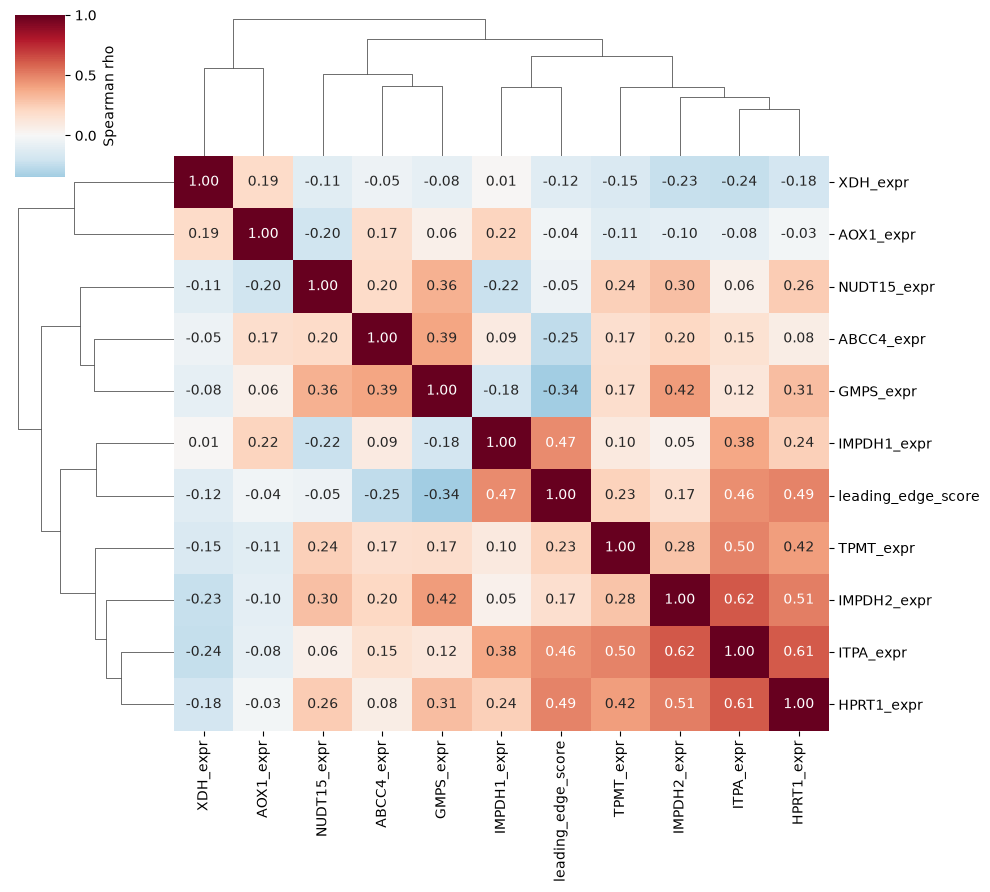

In [61]:
g5 = sns.clustermap(
    corr_matrix,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    figsize=(10, 9),
    cbar_kws={"label": "Spearman rho"}
)
plt.savefig(f"{pycharm_dir}/thiopurine_pathway_correlation_clustermap.png", dpi=300, bbox_inches="tight")
plt.show()

  gene_symbol  log2FoldChange        pvalue      padj
7        TPMT        0.500151  5.960676e-07  0.000035
4      IMPDH2        0.388319  5.070586e-06  0.000175
5        ITPA        0.360981  2.638955e-04  0.003162
3      IMPDH1        0.363618  1.577713e-03  0.011542
2       HPRT1        0.265954  1.070388e-02  0.045246
0       ABCC4       -0.244198  5.546007e-02  0.146602
8        TYMS       -0.094273  3.289236e-01  0.497630
1        GMPS        0.036153  5.388912e-01  0.685378
6      NUDT15        0.045732  5.812741e-01  0.719342


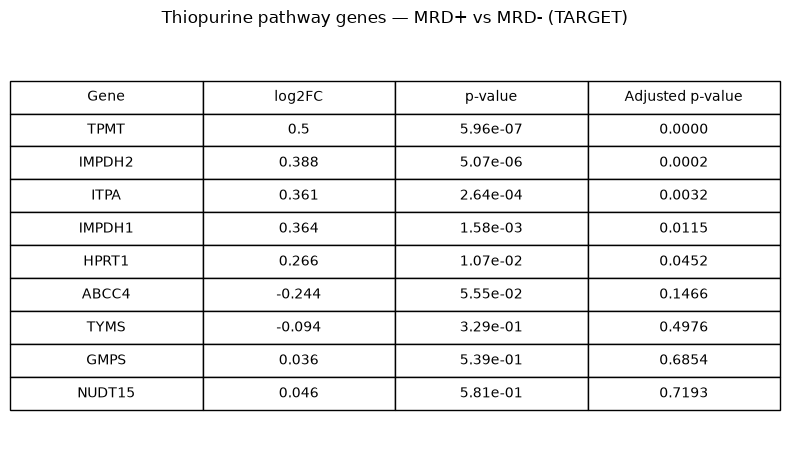

In [62]:
thiopurine_genes = ['TPMT', 'NUDT15', 'ITPA', 'HPRT1', 'IMPDH1', 'IMPDH2', 'GMPS', 'ABCC4', 'TYMS']

target_thiopurine = results_df.loc[
    results_df.index.isin(thiopurine_genes)
].copy()
target_thiopurine = target_thiopurine.reset_index()
target_thiopurine = target_thiopurine.rename(columns={'gene_name': 'gene_symbol'})
target_thiopurine = target_thiopurine[['gene_symbol', 'log2FoldChange', 'pvalue', 'padj']]
target_thiopurine = target_thiopurine.sort_values('padj')

print(target_thiopurine)
target_thiopurine.to_csv('thiopurine_pathway_target_mrd_pvalues.csv', index=False)

import matplotlib.pyplot as plt

table_df = target_thiopurine.copy()
table_df['log2FoldChange'] = table_df['log2FoldChange'].round(3)
table_df['pvalue'] = table_df['pvalue'].apply(lambda x: f"{x:.2e}")
table_df['padj'] = table_df['padj'].apply(lambda x: f"{x:.4f}")

table_df = table_df.rename(columns={
    'gene_symbol': 'Gene',
    'log2FoldChange': 'log2FC',
    'pvalue': 'p-value',
    'padj': 'Adjusted p-value'
})

fig, ax = plt.subplots(figsize=(8, 0.4 * len(table_df) + 1))
ax.axis('off')
tbl = ax.table(cellText=table_df.values, colLabels=table_df.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)
plt.title('Thiopurine pathway genes — MRD+ vs MRD- (TARGET)', pad=20)
plt.tight_layout()
plt.savefig('thiopurine_pathway_target_table.png', dpi=300, bbox_inches='tight')
plt.show()

## 15. External Clinical Covariates: Protocol, WBC, Age, Survival

In [63]:
import requests, io

file_id = "19889559-1020-4fe3-b81e-b2eaa3f5b16c"
data_endpt = f"https://api.gdc.cancer.gov/data/{file_id}"

response = requests.get(data_endpt)
xlsx_bytes = io.BytesIO(response.content)

discovery_clinical = pd.read_excel(xlsx_bytes, sheet_name="Clinical Data")
print(discovery_clinical.shape)
print(discovery_clinical[['TARGET USI', 'Protocol', 'WBC at Diagnosis']].head())

(230, 44)
         TARGET USI Protocol  WBC at Diagnosis
0  TARGET-10-PAKMVD    P9906              82.9
1  TARGET-10-PAKMZM    P9906             114.6
2  TARGET-10-PAKRSL    P9906             321.2
3  TARGET-10-PAKSWW    P9906             202.4
4  TARGET-10-PALJCF    P9906             214.0


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [64]:
clinical_extra = discovery_clinical[['TARGET USI', 'Protocol', 'WBC at Diagnosis']].set_index('TARGET USI')

analysis_df4 = analysis_df3.merge(clinical_extra, left_index=True, right_index=True, how="left")

print(analysis_df4[['Protocol', 'WBC at Diagnosis']].isna().sum())
print(analysis_df4['Protocol'].value_counts(dropna=False))

Protocol            245
WBC at Diagnosis    245
dtype: int64
Protocol
NaN         245
AALL0232     78
AALL0331     52
Name: count, dtype: int64


In [65]:
protocol_available = analysis_df4.dropna(subset=['Protocol'])
print(protocol_available.shape)
print(protocol_available['mrd_status'].value_counts())
print(pd.crosstab(protocol_available['Protocol'], protocol_available['mrd_status']))

(130, 17)
mrd_status
MRD_neg    76
MRD_pos    54
Name: count, dtype: int64
mrd_status  MRD_neg  MRD_pos
Protocol                    
AALL0232         39       39
AALL0331         37       15


In [66]:
protocol_groups = [protocol_available.loc[protocol_available['Protocol']==p, 'TPMT_expr'] 
                    for p in ['AALL0232', 'AALL0331']]
stat, p_protocol = mannwhitneyu(protocol_groups[0], protocol_groups[1], alternative='two-sided')
print(f"TPMT by protocol (AALL0232 vs AALL0331): p={p_protocol:.4f}")

rho_wbc, p_wbc = spearmanr(protocol_available['WBC at Diagnosis'], protocol_available['TPMT_expr'])
print(f"TPMT vs WBC at diagnosis: rho={rho_wbc:.3f}, p={p_wbc:.4f}")

TPMT by protocol (AALL0232 vs AALL0331): p=0.0649
TPMT vs WBC at diagnosis: rho=-0.137, p=0.1207


-  TPMT expression does not differ significantly by protocol (p=0.0649)
-  WBC at diagnosis does not significantly correlate with TPMT (p=0.1207)

In [67]:
# check if TPMT-MRD relationship survives when both included in the model 
model_df2 = protocol_available[protocol_available['subtype'] != 'Unclassified'].copy()
print(model_df2.shape)

model2 = smf.ols("TPMT_expr ~ mrd_status + Protocol", data=model_df2).fit()
print(model2.summary())

(124, 17)
                            OLS Regression Results                            
Dep. Variable:              TPMT_expr   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     3.330
Date:                Tue, 08 Sep 2026   Prob (F-statistic):             0.0391
Time:                        14:11:14   Log-Likelihood:                -141.05
No. Observations:                 124   AIC:                             288.1
Df Residuals:                     121   BIC:                             296.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept           

On the smaller n=124 subset, the MRD effect on TPMT expression drops to p=0.066 and is no longer significant at the 0.05 threshold (coef=0.27). Protocol itself is significant (p=0.032), with AALL0331 patients showing higher TPMT (coef=0.31).

In [68]:
clinical_focus = discovery_clinical.set_index('TARGET USI')[[
    'Age at Diagnosis in Days', 'Overall Survival Time in Days', 'Vital Status'
]]

analysis_df5 = analysis_df3.merge(clinical_focus, left_index=True, right_index=True, how="left")
print(analysis_df5.shape)
print(analysis_df5[clinical_focus.columns].isna().sum())
print(analysis_df5['Vital Status'].value_counts(dropna=False))

(375, 18)
Age at Diagnosis in Days         245
Overall Survival Time in Days    245
Vital Status                     245
dtype: int64
Vital Status
NaN      245
Dead      72
Alive     58
Name: count, dtype: int64


In [69]:
valid = analysis_df5[['Age at Diagnosis in Days', 'TPMT_expr']].dropna()
print(valid.shape)

rho_age, p_age = spearmanr(valid['Age at Diagnosis in Days'], valid['TPMT_expr'])
print(f"TPMT vs Age at Diagnosis: rho={rho_age:.3f}, p={p_age:.4f}")

(130, 2)
TPMT vs Age at Diagnosis: rho=-0.013, p=0.8855


In [70]:
dead_vals = analysis_df5.loc[analysis_df5['Vital Status']=='Dead', 'TPMT_expr']
alive_vals = analysis_df5.loc[analysis_df5['Vital Status']=='Alive', 'TPMT_expr']
stat, p_vital = mannwhitneyu(dead_vals, alive_vals, alternative='two-sided')
print(f"TPMT expr: Dead mean={dead_vals.mean():.3f}, Alive mean={alive_vals.mean():.3f}, p={p_vital:.4f}")

TPMT expr: Dead mean=2.726, Alive mean=2.802, p=0.5473


In [71]:
dead_only = analysis_df5[(analysis_df5['Vital Status'] == 'Dead')].dropna(subset=['Overall Survival Time in Days', 'TPMT_expr'])
print(dead_only.shape)

rho_surv, p_surv = spearmanr(dead_only['Overall Survival Time in Days'], dead_only['TPMT_expr'])
print(f"TPMT vs Overall Survival Time (dead patients only): rho={rho_surv:.3f}, p={p_surv:.4f}")

(72, 18)
TPMT vs Overall Survival Time (dead patients only): rho=-0.135, p=0.2597


#### Classifier ####

In [72]:
#check imbalance 
import pandas as pd

print(meta['mrd_status'].value_counts())
print(meta['mrd_status'].value_counts(normalize=True))

mrd_status
MRD_neg    243
MRD_pos    132
Name: count, dtype: int64
mrd_status
MRD_neg    0.648
MRD_pos    0.352
Name: proportion, dtype: float64


Mild imbalance 65/35 (243 MRD- vs 132 MRD+). Should use class_weight='balanced' and report PR-AUC alongside ROC-AUC rather than relying on accuracy.

##### Phase 1: TPMT + NUDT15 only #####

In [73]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# --- Build the modeling dataframe ---
model_data = protocol_available.copy()  # must contain: mrd_status, TPMT_expr, NUDT15_expr, subtype, Protocol

y = (model_data['mrd_status'] == 'MRD_pos').astype(int)

# Model A: gene expression only
X_a = model_data[['TPMT_expr', 'NUDT15_expr']]

# Model B: gene expression + subtype + protocol
X_b = model_data[['TPMT_expr', 'NUDT15_expr', 'subtype', 'Protocol']]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'average_precision', 'f1']

# --- Model A pipeline ---
pipe_a = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

results_a = cross_validate(pipe_a, X_a, y, cv=cv, scoring=scoring)

print("=== Model A: TPMT + NUDT15 only ===")
print(f"ROC-AUC: {results_a['test_roc_auc'].mean():.3f} ± {results_a['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_a['test_average_precision'].mean():.3f} ± {results_a['test_average_precision'].std():.3f}")
print(f"F1:      {results_a['test_f1'].mean():.3f} ± {results_a['test_f1'].std():.3f}")

# --- Model B pipeline (handles categorical subtype/protocol) ---
preprocess_b = ColumnTransformer([
    ('num', StandardScaler(), ['TPMT_expr', 'NUDT15_expr']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['subtype', 'Protocol'])
])

pipe_b = Pipeline([
    ('prep', preprocess_b),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

results_b = cross_validate(pipe_b, X_b, y, cv=cv, scoring=scoring)

print("\n=== Model B: + subtype + protocol ===")
print(f"ROC-AUC: {results_b['test_roc_auc'].mean():.3f} ± {results_b['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_b['test_average_precision'].mean():.3f} ± {results_b['test_average_precision'].std():.3f}")
print(f"F1:      {results_b['test_f1'].mean():.3f} ± {results_b['test_f1'].std():.3f}")

=== Model A: TPMT + NUDT15 only ===
ROC-AUC: 0.537 ± 0.150
PR-AUC:  0.504 ± 0.105
F1:      0.434 ± 0.186

=== Model B: + subtype + protocol ===
ROC-AUC: 0.714 ± 0.116
PR-AUC:  0.666 ± 0.124
F1:      0.619 ± 0.080


**Model A (genes only)**: ROC-AUC 0.537± 0.150 - barely above random chance. TPMT and NUDT15 expression alone carry little predictive signal for MRD status.

**Model B (+subtype + protocol)**: ROC-AUC 0.714 ± 0.116 - most likely subtype/protocol doing the work, not the genes. Must check directly. 

In [74]:
# isolate what subtype+protocol alone can do, no genes at all
X_c = model_data[['subtype', 'Protocol']]
preprocess_c = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['subtype', 'Protocol'])
])
pipe_c = Pipeline([
    ('prep', preprocess_c),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])
results_c = cross_validate(pipe_c, X_c, y, cv=cv, scoring=scoring)

print("=== Model C: subtype + protocol only (no genes) ===")
print(f"ROC-AUC: {results_c['test_roc_auc'].mean():.3f} ± {results_c['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_c['test_average_precision'].mean():.3f} ± {results_c['test_average_precision'].std():.3f}")
print(f"F1:      {results_c['test_f1'].mean():.3f} ± {results_c['test_f1'].std():.3f}")

=== Model C: subtype + protocol only (no genes) ===
ROC-AUC: 0.692 ± 0.074
PR-AUC:  0.642 ± 0.084
F1:      0.590 ± 0.105


**Model C (0.694)≈ Model B (0.714)** - nearly identical, well within each other's variability. The genes are adding nothing on top of subtype and protocol. Most of Model B's predictive power comes form subtype/protocol, not TPMT/NUDT15.

Attempted to build classifier again using expression data of other genes in the thiopurine metabolism pathway. 

In [75]:
from sklearn.linear_model import LogisticRegressionCV

# Model D: full thiopurine pathway genes only (no subtype/protocol)
pathway_cols = [f"{g}_expr" for g in thiopurine_pathway_genes]
print(f"Pathway genes used: {pathway_cols}")

X_d = model_data[pathway_cols]

pipe_d = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear',
                                class_weight='balanced', max_iter=1000))
])
results_d = cross_validate(pipe_d, X_d, y, cv=cv, scoring=scoring)

print("=== Model D: thiopurine pathway genes only (L1) ===")
print(f"ROC-AUC: {results_d['test_roc_auc'].mean():.3f} ± {results_d['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_d['test_average_precision'].mean():.3f} ± {results_d['test_average_precision'].std():.3f}")
print(f"F1:      {results_d['test_f1'].mean():.3f} ± {results_d['test_f1'].std():.3f}")

# Model E: pathway genes + subtype + protocol
preprocess_e = ColumnTransformer([
    ('num', StandardScaler(), pathway_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['subtype', 'Protocol'])
])
pipe_e = Pipeline([
    ('prep', preprocess_e),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear',
                                class_weight='balanced', max_iter=1000))
])
X_e = model_data[pathway_cols + ['subtype', 'Protocol']]
results_e = cross_validate(pipe_e, X_e, y, cv=cv, scoring=scoring)

print("\n=== Model E: pathway genes + subtype + protocol (L1) ===")
print(f"ROC-AUC: {results_e['test_roc_auc'].mean():.3f} ± {results_e['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_e['test_average_precision'].mean():.3f} ± {results_e['test_average_precision'].std():.3f}")
print(f"F1:      {results_e['test_f1'].mean():.3f} ± {results_e['test_f1'].std():.3f}")

Pathway genes used: ['ITPA_expr', 'ABCC4_expr', 'XDH_expr', 'AOX1_expr', 'HPRT1_expr', 'GMPS_expr', 'IMPDH1_expr', 'IMPDH2_expr']
=== Model D: thiopurine pathway genes only (L1) ===
ROC-AUC: 0.609 ± 0.051
PR-AUC:  0.551 ± 0.074
F1:      0.548 ± 0.014

=== Model E: pathway genes + subtype + protocol (L1) ===
ROC-AUC: 0.698 ± 0.068
PR-AUC:  0.642 ± 0.100
F1:      0.569 ± 0.068


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/

In [76]:
pipe_d.fit(X_d, y)
coefs = pipe_d.named_steps['clf'].coef_[0]
for gene, c in zip(pathway_cols, coefs):
    print(f"{gene}: {c:.4f}")

ITPA_expr: 0.2337
ABCC4_expr: -0.0128
XDH_expr: 0.0000
AOX1_expr: -0.3114
HPRT1_expr: -0.0921
GMPS_expr: -0.0454
IMPDH1_expr: 0.1625
IMPDH2_expr: 0.3049


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


**Extending Model D/E to the full cohort (not just the n=150 protocol-annotated subset):**

In [77]:
model_data_full = analysis_df.copy()
print(model_data_full[['mrd_status', 'TPMT_expr', 'NUDT15_expr', 'subtype']].isna().sum())
model_data_full = model_data_full.dropna(subset=['mrd_status', 'TPMT_expr', 'NUDT15_expr', 'subtype'])
print(model_data_full.shape)

y_full = (model_data_full['mrd_status'] == 'MRD_pos').astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'average_precision', 'f1']

# --- Model A': TPMT + NUDT15 only, full cohort ---
X_a_full = model_data_full[['TPMT_expr', 'NUDT15_expr']]
pipe_a = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])
results_a_full = cross_validate(pipe_a, X_a_full, y_full, cv=cv, scoring=scoring)
print("=== Model A': TPMT + NUDT15 only (full cohort, n={}) ===".format(len(model_data_full)))
print(f"ROC-AUC: {results_a_full['test_roc_auc'].mean():.3f} ± {results_a_full['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_a_full['test_average_precision'].mean():.3f} ± {results_a_full['test_average_precision'].std():.3f}")
print(f"F1:      {results_a_full['test_f1'].mean():.3f} ± {results_a_full['test_f1'].std():.3f}")

# --- Model C': subtype only, full cohort ---
X_c_full = model_data_full[['subtype']]
preprocess_c = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), ['subtype'])])
pipe_c = Pipeline([('prep', preprocess_c), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))])
results_c_full = cross_validate(pipe_c, X_c_full, y_full, cv=cv, scoring=scoring)
print("\n=== Model C': subtype only (full cohort) ===")
print(f"ROC-AUC: {results_c_full['test_roc_auc'].mean():.3f} ± {results_c_full['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_c_full['test_average_precision'].mean():.3f} ± {results_c_full['test_average_precision'].std():.3f}")
print(f"F1:      {results_c_full['test_f1'].mean():.3f} ± {results_c_full['test_f1'].std():.3f}")

# --- Model B': TPMT + NUDT15 + subtype, full cohort ---
X_b_full = model_data_full[['TPMT_expr', 'NUDT15_expr', 'subtype']]
preprocess_b = ColumnTransformer([
    ('num', StandardScaler(), ['TPMT_expr', 'NUDT15_expr']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['subtype'])
])
pipe_b = Pipeline([('prep', preprocess_b), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))])
results_b_full = cross_validate(pipe_b, X_b_full, y_full, cv=cv, scoring=scoring)
print("\n=== Model B': TPMT + NUDT15 + subtype (full cohort) ===")
print(f"ROC-AUC: {results_b_full['test_roc_auc'].mean():.3f} ± {results_b_full['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_b_full['test_average_precision'].mean():.3f} ± {results_b_full['test_average_precision'].std():.3f}")
print(f"F1:      {results_b_full['test_f1'].mean():.3f} ± {results_b_full['test_f1'].std():.3f}")

mrd_status     0
TPMT_expr      0
NUDT15_expr    0
subtype        0
dtype: int64
(375, 5)
=== Model A': TPMT + NUDT15 only (full cohort, n=375) ===
ROC-AUC: 0.627 ± 0.060
PR-AUC:  0.513 ± 0.074
F1:      0.500 ± 0.055

=== Model C': subtype only (full cohort) ===
ROC-AUC: 0.585 ± 0.028
PR-AUC:  0.452 ± 0.040
F1:      0.411 ± 0.054

=== Model B': TPMT + NUDT15 + subtype (full cohort) ===
ROC-AUC: 0.648 ± 0.065
PR-AUC:  0.552 ± 0.074
F1:      0.497 ± 0.091


In [78]:
model_data_full2 = analysis_df2.copy()
pathway_cols = [f"{g}_expr" for g in thiopurine_pathway_genes]
check_cols = ['mrd_status', 'subtype', 'TPMT_expr', 'NUDT15_expr'] + pathway_cols
print(model_data_full2[check_cols].isna().sum())
model_data_full2 = model_data_full2.dropna(subset=check_cols)
print(model_data_full2.shape)

y_full2 = (model_data_full2['mrd_status'] == 'MRD_pos').astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'average_precision', 'f1']

# --- Model D': pathway genes only, full cohort ---
X_d_full = model_data_full2[pathway_cols]
pipe_d = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear',
                                class_weight='balanced', max_iter=1000))
])
results_d_full = cross_validate(pipe_d, X_d_full, y_full2, cv=cv, scoring=scoring)
print("=== Model D': pathway genes only (full cohort, n={}) ===".format(len(model_data_full2)))
print(f"ROC-AUC: {results_d_full['test_roc_auc'].mean():.3f} ± {results_d_full['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_d_full['test_average_precision'].mean():.3f} ± {results_d_full['test_average_precision'].std():.3f}")
print(f"F1:      {results_d_full['test_f1'].mean():.3f} ± {results_d_full['test_f1'].std():.3f}")

# --- Model E': pathway genes + subtype, full cohort ---
X_e_full = model_data_full2[pathway_cols + ['subtype']]
preprocess_e = ColumnTransformer([
    ('num', StandardScaler(), pathway_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['subtype'])
])
pipe_e = Pipeline([
    ('prep', preprocess_e),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear',
                                class_weight='balanced', max_iter=1000))
])
results_e_full = cross_validate(pipe_e, X_e_full, y_full2, cv=cv, scoring=scoring)
print("\n=== Model E': pathway genes + subtype (full cohort) ===")
print(f"ROC-AUC: {results_e_full['test_roc_auc'].mean():.3f} ± {results_e_full['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_e_full['test_average_precision'].mean():.3f} ± {results_e_full['test_average_precision'].std():.3f}")
print(f"F1:      {results_e_full['test_f1'].mean():.3f} ± {results_e_full['test_f1'].std():.3f}")

# which genes did L1 keep?
pipe_d.fit(X_d_full, y_full2)
coefs = pipe_d.named_steps['clf'].coef_[0]
print("\nNonzero pathway gene coefficients (Model D'):")
for gene, c in zip(pathway_cols, coefs):
    if abs(c) > 1e-6:
        print(f"  {gene}: {c:.4f}")

mrd_status     0
subtype        0
TPMT_expr      0
NUDT15_expr    0
ITPA_expr      0
ABCC4_expr     0
XDH_expr       0
AOX1_expr      0
HPRT1_expr     0
GMPS_expr      0
IMPDH1_expr    0
IMPDH2_expr    0
dtype: int64
(375, 13)


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


=== Model D': pathway genes only (full cohort, n=375) ===
ROC-AUC: 0.629 ± 0.065
PR-AUC:  0.521 ± 0.063
F1:      0.502 ± 0.040

=== Model E': pathway genes + subtype (full cohort) ===
ROC-AUC: 0.674 ± 0.057
PR-AUC:  0.575 ± 0.059
F1:      0.529 ± 0.044

Nonzero pathway gene coefficients (Model D'):
  ITPA_expr: 0.3007
  ABCC4_expr: -0.3988
  XDH_expr: 0.0943
  AOX1_expr: -0.2132
  HPRT1_expr: -0.1112
  IMPDH1_expr: 0.1777
  IMPDH2_expr: 0.2465


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/

In [79]:
all_gene_cols = ['TPMT_expr', 'NUDT15_expr'] + pathway_cols

# Model F: all 10 thiopurine-pathway genes, no subtype
X_f = model_data_full2[all_gene_cols]
pipe_f = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear',
                                class_weight='balanced', max_iter=1000))
])
results_f = cross_validate(pipe_f, X_f, y_full2, cv=cv, scoring=scoring)
print("=== Model F: all 10 genes only (full cohort) ===")
print(f"ROC-AUC: {results_f['test_roc_auc'].mean():.3f} ± {results_f['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_f['test_average_precision'].mean():.3f} ± {results_f['test_average_precision'].std():.3f}")
print(f"F1:      {results_f['test_f1'].mean():.3f} ± {results_f['test_f1'].std():.3f}")

# Model G: all 10 genes + subtype
X_g = model_data_full2[all_gene_cols + ['subtype']]
preprocess_g = ColumnTransformer([
    ('num', StandardScaler(), all_gene_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['subtype'])
])
pipe_g = Pipeline([
    ('prep', preprocess_g),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear',
                                class_weight='balanced', max_iter=1000))
])
results_g = cross_validate(pipe_g, X_g, y_full2, cv=cv, scoring=scoring)
print("\n=== Model G: all 10 genes + subtype (full cohort) ===")
print(f"ROC-AUC: {results_g['test_roc_auc'].mean():.3f} ± {results_g['test_roc_auc'].std():.3f}")
print(f"PR-AUC:  {results_g['test_average_precision'].mean():.3f} ± {results_g['test_average_precision'].std():.3f}")
print(f"F1:      {results_g['test_f1'].mean():.3f} ± {results_g['test_f1'].std():.3f}")

# Coefficient ranking, all 10 genes
pipe_f.fit(X_f, y_full2)
coefs_f = pipe_f.named_steps['clf'].coef_[0]
coef_table = pd.DataFrame({'gene': all_gene_cols, 'coef': coefs_f})
coef_table['abs_coef'] = coef_table['coef'].abs()
coef_table = coef_table.sort_values('abs_coef', ascending=False)
print("\nGene coefficient ranking (Model F, all 10 genes):")
print(coef_table[['gene', 'coef']].to_string(index=False))

/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/

=== Model F: all 10 genes only (full cohort) ===
ROC-AUC: 0.663 ± 0.029
PR-AUC:  0.540 ± 0.060
F1:      0.528 ± 0.054

=== Model G: all 10 genes + subtype (full cohort) ===
ROC-AUC: 0.674 ± 0.026
PR-AUC:  0.576 ± 0.015
F1:      0.536 ± 0.022

Gene coefficient ranking (Model F, all 10 genes):
       gene      coef
  TPMT_expr  0.489544
 ABCC4_expr -0.438444
IMPDH2_expr  0.355660
IMPDH1_expr  0.226442
  AOX1_expr -0.181153
 HPRT1_expr -0.160128
   XDH_expr  0.098074
NUDT15_expr -0.093938
  ITPA_expr  0.037976
  GMPS_expr -0.012350


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/Meralle/PyCharmMiscProject/.venv/lib/

## 17. Final Depth-Corrected UMAP, Clustering & Thesis Figure
The earlier UMAP (Section 10) was confounded by a sequencing-depth batch effect. This final version regresses out depth, restricts to biologically informative genes, and uses a PCA→UMAP (cosine metric) pipeline before running HDBSCAN to look for structure among the ALLSorts-"Unclassified" samples.

In [80]:
true_cohort = mrd_samples 

cpm_correct = expr_matrix[true_cohort].div(expr_matrix[true_cohort].sum(axis=0), axis=1) * 1e6
log_cpm_correct = np.log2(cpm_correct + 1)

In [81]:
true_cohort_list = sorted(true_cohort)
expr_correct = expr_matrix[true_cohort_list]
print(f"Correct expression matrix: {expr_correct.shape}")

clinical_correct = clinical_df[clinical_df['submitter_id'].isin(true_cohort_list)].drop_duplicates(subset='submitter_id')
print(f"Correct clinical data: {clinical_correct.shape}")
print(clinical_correct['mrd_status'].value_counts())

Correct expression matrix: (60660, 375)
Correct clinical data: (375, 19)
mrd_status
MRD_neg    243
MRD_pos    132
Name: count, dtype: int64


In [82]:
# Drop ALL existing subtype columns first (there may be 2 duplicates)
clinical_correct = clinical_correct.loc[:, ~clinical_correct.columns.duplicated()]
# check if a single leftover 'subtype' still exists from clinical_df originally
if 'subtype' in clinical_correct.columns:
    clinical_correct = clinical_correct.drop(columns=['subtype'])

# Now merge in the correct ALLSorts predictions fresh
clinical_correct = clinical_correct.merge(
    allsorts_results[['subtype_primary']],
    left_on='submitter_id', right_index=True, how='left'
)
clinical_correct = clinical_correct.rename(columns={'subtype_primary': 'subtype'})

print(clinical_correct.columns.tolist())
print(clinical_correct['subtype'].isna().sum(), "samples with no ALLSorts prediction")
print(clinical_correct['subtype'].value_counts(dropna=False))

['submitter_id', 'gender', 'race', 'ethnicity', 'vital_status', 'age_at_diagnosis_days', 'days_to_last_follow_up', 'morphology', 'progression_or_recurrence', 'therapeutic_agents', 'treatment_outcome', 'disease_response', 'mrd_value_eoi', 'mrd_status', 'mrd_days_to_test', 'mrd_timepoint_category', 'n_mrd_entries', 'age_at_diagnosis_years', 'subtype']
0 samples with no ALLSorts prediction
subtype
Unclassified         194
Ph-like               40
High hyperdiploid     30
PAX5alt               29
KMT2A Group           14
TCF3-PBX1             13
ZNF384 Group          10
ETV6-RUNX1             9
High Sig               7
MEF2D                  5
Ph                     5
HLF                    3
Low hyperdiploid       3
ETV6-RUNX1-like        3
iAMP21                 2
Ph Group               2
NUTM1                  2
PAX5 P80R              2
DUX4                   1
ETV6-RUNX1 Group       1
Name: count, dtype: int64


In [83]:
import numpy as np
import pandas as pd
import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP

# --- DEDUPLICATION STEP (Fixes DuplicateError) ---
# Deduplicate genes in log_cpm_correct by taking the mean across duplicate rows
if log_cpm_correct.index.has_duplicates:
    print(f"Resolving {log_cpm_correct.index.duplicated().sum()} duplicate gene symbols...")
    log_cpm_correct = log_cpm_correct.groupby(level=0).mean()

# 2. Filter to biologically informative genes
sex_genes = {'XIST', 'RPS4Y1', 'DDX3Y', 'KDM5D', 'UTY', 'USP9Y', 'EIF1AY', 'ZFY', 'NLGN4Y', 'TXLNGY'}

def is_low_confidence(gene_name):
    gene_name = str(gene_name)
    if gene_name in sex_genes or gene_name.startswith('MT-'):
        return True
    noncoding_prefixes = ('SNORD', 'SNORA', 'SCARNA', 'RNU', 'RN7SL', 'RN7SK', 'MIR', 'RNVU', 'RMRP', 'LINC')
    if gene_name.startswith(noncoding_prefixes):
        return True
    exact_excludes = {'Y_RNA', 'Metazoa_SRP', '7SK', '5S_rRNA'}
    if gene_name in exact_excludes:
        return True
    if re.match(r'^(AL|AC|AP|AF|BX|CU|FP)\d+\.\d+', gene_name, re.IGNORECASE):
        return True
    if re.search(r'[-.]P\d+$', gene_name) or re.match(r'^RP\d+[-.]', gene_name):
        return True
    return False

valid_genes_correct = [g for g in log_cpm_correct.index if not is_low_confidence(g)]

# 3. Select top 2000 variable genes
gene_var_correct = log_cpm_correct.loc[valid_genes_correct].var(axis=1)
top_genes_correct = gene_var_correct.sort_values(ascending=False).head(2000).index

# 4. Dimension Reduction
hvg_correct = log_cpm_correct.loc[top_genes_correct].T  # samples x genes

# Pass values array to StandardScaler to completely avoid Pandas column name validation:
scaler = StandardScaler()
X_scaled_correct = scaler.fit_transform(hvg_correct.values)

pca_correct = PCA(n_components=30, random_state=42)
pcs_correct = pca_correct.fit_transform(X_scaled_correct)
pcs_filtered_correct = pcs_correct[:, 2:]  # drop PC1-2

reducer_correct = UMAP(n_neighbors=25, min_dist=0.1, metric='cosine', random_state=42)
embedding_correct = reducer_correct.fit_transform(pcs_filtered_correct)

umap_correct_df = pd.DataFrame(embedding_correct, columns=["UMAP1", "UMAP2"], index=hvg_correct.index)
umap_correct_df = umap_correct_df.merge(
    clinical_correct.set_index('submitter_id')[['subtype', 'mrd_status']],
    left_index=True, right_index=True, how='left'
)

print("UMAP Matrix Shape:", umap_correct_df.shape)
print("\nSubtype breakdown across all patients:")
print(umap_correct_df['subtype'].value_counts(dropna=False))

Resolving 1233 duplicate gene symbols...


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP Matrix Shape: (375, 4)

Subtype breakdown across all patients:
subtype
Unclassified         194
Ph-like               40
High hyperdiploid     30
PAX5alt               29
KMT2A Group           14
TCF3-PBX1             13
ZNF384 Group          10
ETV6-RUNX1             9
High Sig               7
MEF2D                  5
Ph                     5
HLF                    3
ETV6-RUNX1-like        3
Low hyperdiploid       3
PAX5 P80R              2
iAMP21                 2
Ph Group               2
NUTM1                  2
ETV6-RUNX1 Group       1
DUX4                   1
Name: count, dtype: int64


In [84]:
# Map redundant subtypes to clean, standardized categories
subtype_mapping = {
    'Ph Group': 'Ph',
    'ETV6-RUNX1 Group': 'ETV6-RUNX1',
    'ETV6-RUNX1-like': 'ETV6-RUNX1-like', # Keep separate from canonical ETV6-RUNX1 if distinct
}

# Optional: Group ultra-rare subtypes (< 3 samples) into "Other Rare" for cleaner plotting
rare_subtypes = ['DUX4', 'NUTM1', 'PAX5 P80R']

def consolidate_subtypes(st):
    st = subtype_mapping.get(st, st)
    if st in rare_subtypes:
        return 'Other Rare'
    return st

umap_correct_df['subtype_clean'] = umap_correct_df['subtype'].apply(consolidate_subtypes)

=== Cluster Composition Breakdown ===
subtype              DUX4  ETV6-RUNX1  ETV6-RUNX1 Group  ETV6-RUNX1-like  HLF  \
hdbscan_cluster_str                                                             
Cluster 0               0           0                 0                0    0   
Cluster 1               0           0                 0                0    0   
Cluster 10              0           0                 0                0    0   
Cluster 11              0           0                 0                0    0   
Cluster 12              0           0                 0                0    0   
Cluster 13              0           0                 0                0    1   
Cluster 14              1           0                 0                0    0   
Cluster 15              0           0                 0                0    0   
Cluster 16              0           0                 0                0    0   
Cluster 17              0           0                 0                

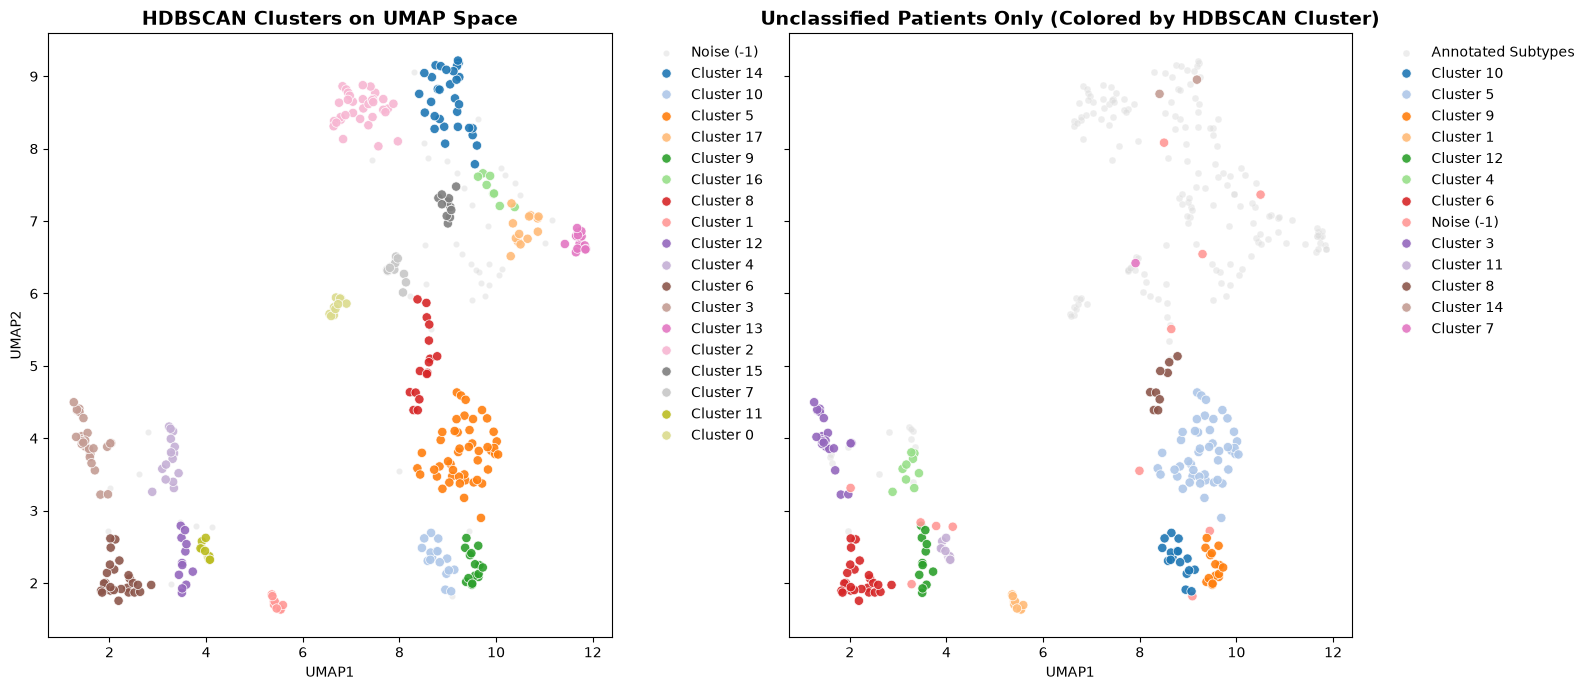

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import built-in HDBSCAN from sklearn instead of the standalone package
from sklearn.cluster import HDBSCAN

# 1. Fit HDBSCAN on UMAP 2D coordinates
# sklearn's HDBSCAN uses min_cluster_size and min_samples similarly
clusterer = HDBSCAN(min_cluster_size=8, min_samples=5, metric='euclidean')
umap_correct_df['hdbscan_cluster'] = clusterer.fit_predict(umap_correct_df[['UMAP1', 'UMAP2']])

# 2. Map cluster IDs to string labels (-1 represents unclustered noise)
umap_correct_df['hdbscan_cluster_str'] = umap_correct_df['hdbscan_cluster'].apply(
    lambda c: 'Noise (-1)' if c == -1 else f'Cluster {c}'
)

# 3. Analyze the breakdown of Unclassified vs. Annotated samples across clusters
cluster_composition = pd.crosstab(
    umap_correct_df['hdbscan_cluster_str'], 
    umap_correct_df['subtype'].fillna('Unclassified'), 
    margins=True
)

print("=== Cluster Composition Breakdown ===")
print(cluster_composition)

# 4. Identify potential "Novel Unclassified Clusters"
cluster_summary = pd.crosstab(
    umap_correct_df['hdbscan_cluster_str'], 
    umap_correct_df['subtype'] == 'Unclassified'
)
cluster_summary.columns = ['Annotated_Count', 'Unclassified_Count']
cluster_summary['Total'] = cluster_summary['Annotated_Count'] + cluster_summary['Unclassified_Count']
cluster_summary['Pct_Unclassified'] = (cluster_summary['Unclassified_Count'] / cluster_summary['Total']) * 100

print("\n=== Clusters Enriched for Unclassified Samples ===")
print(cluster_summary.sort_values(by='Pct_Unclassified', ascending=False))

# 5. Visualizations: Side-by-Side UMAP Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Panel A: All HDBSCAN Clusters
sns.scatterplot(
    data=umap_correct_df[umap_correct_df['hdbscan_cluster'] == -1],
    x='UMAP1', y='UMAP2', color='lightgrey', alpha=0.4, s=20, label='Noise (-1)', ax=axes[0]
)
sns.scatterplot(
    data=umap_correct_df[umap_correct_df['hdbscan_cluster'] != -1],
    x='UMAP1', y='UMAP2', hue='hdbscan_cluster_str', palette='tab20', s=45, alpha=0.9, ax=axes[0]
)
axes[0].set_title("HDBSCAN Clusters on UMAP Space", fontsize=14, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

# Panel B: Highlighting Unclassified Patients
umap_correct_df['is_unclassified'] = umap_correct_df['subtype'] == 'Unclassified'
sns.scatterplot(
    data=umap_correct_df[~umap_correct_df['is_unclassified']],
    x='UMAP1', y='UMAP2', color='gainsboro', alpha=0.5, s=25, label='Annotated Subtypes', ax=axes[1]
)
sns.scatterplot(
    data=umap_correct_df[umap_correct_df['is_unclassified']],
    x='UMAP1', y='UMAP2', hue='hdbscan_cluster_str', palette='tab20', s=45, alpha=0.9, ax=axes[1]
)
axes[1].set_title("Unclassified Patients Only (Colored by HDBSCAN Cluster)", fontsize=14, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig("UMAP_hdbscan_cluster_composition.png", dpi=300, bbox_inches='tight')
plt.show()

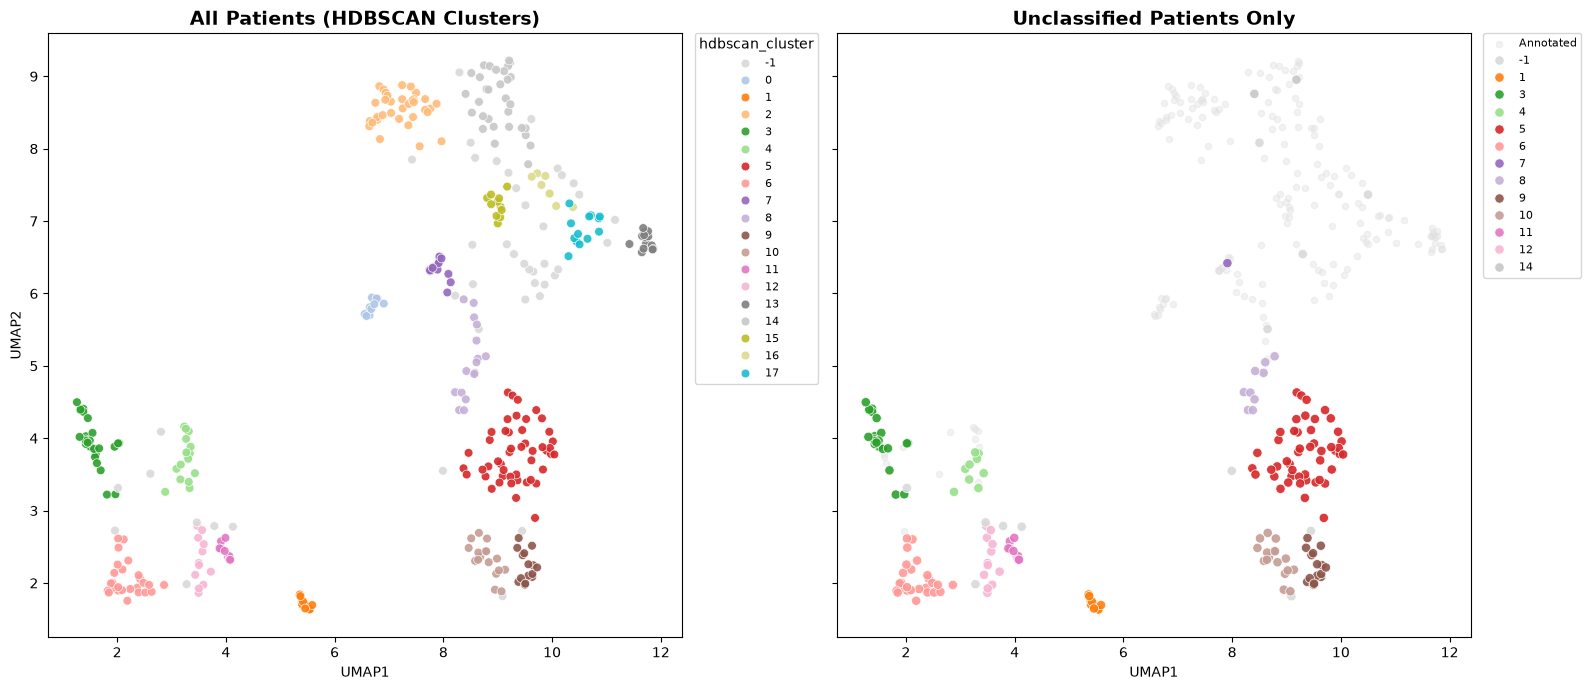

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a fixed color map for every cluster so colors remain identical across both panels
unique_clusters = sorted(umap_correct_df['hdbscan_cluster'].unique())
palette_colors = sns.color_palette("tab20", len(unique_clusters))
cluster_palette = {cluster: color for cluster, color in zip(unique_clusters, palette_colors)}
cluster_palette[-1] = (0.85, 0.85, 0.85)  # Force Noise (-1) to light grey

umap_correct_df['hdbscan_str'] = umap_correct_df['hdbscan_cluster'].apply(
    lambda c: 'Noise (-1)' if c == -1 else f'Cluster {c}'
)

# 2. Plot side-by-side with locked color palette
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Panel A: All Patients
sns.scatterplot(
    data=umap_correct_df,
    x='UMAP1', y='UMAP2',
    hue='hdbscan_cluster',
    palette=cluster_palette,
    s=40, alpha=0.9, ax=axes[0]
)
axes[0].set_title("All Patients (HDBSCAN Clusters)", fontsize=14, fontweight='bold')
axes[0].legend(
    title='hdbscan_cluster',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0, frameon=True, fontsize=8
)

# Panel B: Unclassified Patients Only
unclassified_df = umap_correct_df[umap_correct_df['subtype'] == 'Unclassified']
annotated_df = umap_correct_df[umap_correct_df['subtype'] != 'Unclassified']

axes[1].scatter(annotated_df['UMAP1'], annotated_df['UMAP2'], color='#E0E0E0', s=20, alpha=0.4, label='Annotated')

sns.scatterplot(
    data=unclassified_df,
    x='UMAP1', y='UMAP2',
    hue='hdbscan_cluster',
    palette=cluster_palette,
    s=45, alpha=0.9, ax=axes[1]
)
axes[1].set_title("Unclassified Patients Only", fontsize=14, fontweight='bold')
axes[1].legend(
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0, frameon=True, fontsize=8
)

plt.tight_layout()
plt.savefig("UMAP_hdbscan_unclassified_novel_clusters.png", dpi=300, bbox_inches='tight')
plt.show()

In [88]:
import pandas as pd
import numpy as np
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

# 1. Filter expression matrix to valid protein-coding genes
filtered_log_cpm = log_cpm_correct.loc[valid_genes_correct]
expr_matrix = filtered_log_cpm.values 
genes = filtered_log_cpm.index.values

# Define the unclassified target clusters in the top region
target_clusters = [6, 9, 2, 7, 8, 3, 4]

de_summary_list = []

print("Running Differential Expression across top Unclassified clusters...")

for c in target_clusters:
    cluster_mask = (umap_correct_df['hdbscan_cluster'] == c).values
    other_mask = ~cluster_mask
    
    cluster_degs = []
    for i, gene in enumerate(genes):
        group1 = expr_matrix[i, cluster_mask]
        group2 = expr_matrix[i, other_mask]
        
        stat, pval = ranksums(group1, group2)
        log2fc = np.mean(group1) - np.mean(group2)
        cluster_degs.append({'cluster': f'Cluster {c}', 'gene': gene, 'log2FC': log2fc, 'pvalue': pval})
        
    df_c = pd.DataFrame(cluster_degs)
    _, df_c['fdr_qval'], _, _ = multipletests(df_c['pvalue'], method='fdr_bh')
    
    # Extract top 3 over-expressed markers per cluster
    top_markers = df_c[df_c['fdr_qval'] < 0.05].sort_values(by='log2FC', ascending=False).head(3)
    de_summary_list.append(top_markers)

# Combine into master table
unclassified_markers = pd.concat(de_summary_list, ignore_index=True)
print("\n=== Top Markers for Novel Unclassified Clusters ===")
print(unclassified_markers[['cluster', 'gene', 'log2FC', 'fdr_qval']].to_string(index=False))

Running Differential Expression across top Unclassified clusters...

=== Top Markers for Novel Unclassified Clusters ===
  cluster    gene   log2FC     fdr_qval
Cluster 6    TLX3 5.271933 1.995908e-11
Cluster 6  NDFIP2 5.050383 6.035307e-12
Cluster 6 SCGB3A1 4.634197 1.740290e-11
Cluster 9 ALDH1A2 5.595489 6.988640e-05
Cluster 9    SIX6 5.520204 3.423726e-06
Cluster 9  IGFBP5 5.441447 3.423726e-06
Cluster 2 S100A16 6.693654 2.026938e-15
Cluster 2     NPY 5.851577 7.328740e-16
Cluster 2  DDIT4L 5.334116 3.995217e-16
Cluster 7   KCNN1 6.915995 1.427765e-05
Cluster 7 IGF2BP1 6.262987 1.427765e-05
Cluster 7    PCLO 6.074125 1.427765e-05
Cluster 8   THBS1 3.341280 1.597818e-04
Cluster 8     LYZ 3.304509 2.244440e-04
Cluster 8    VCAN 3.217045 2.244440e-04
Cluster 3   HPGDS 4.155659 1.178425e-10
Cluster 3    MGLL 3.963672 3.211717e-12
Cluster 3    TRDC 3.702317 3.681678e-08
Cluster 4   GFRA1 6.536678 4.706898e-06
Cluster 4   HOXA9 5.580629 1.823189e-07
Cluster 4   HOXA5 5.298665 1.823189e-07

In [89]:
# Map top-half HDBSCAN clusters to safe, defensible thesis labels
hdbscan_to_ambiguous = {
    6: 'Lineage-Ambiguous (Subgroup 1)',
    9: 'Lineage-Ambiguous (Subgroup 2)',
    2: 'Lineage-Ambiguous (Subgroup 3)',
    7: 'Lineage-Ambiguous (Subgroup 4)',
    8: 'Lineage-Ambiguous (Subgroup 5)',
    3: 'Lineage-Ambiguous (Subgroup 6)',
    4: 'Lineage-Ambiguous (Subgroup 7)'
}

# 1. Create updated subtype column
umap_correct_df['thesis_subtype'] = umap_correct_df['subtype'].copy()

# 2. Overwrite 'Unclassified' entries in those target HDBSCAN clusters
for cluster_id, label in hdbscan_to_ambiguous.items():
    mask = (umap_correct_df['subtype'] == 'Unclassified') & (umap_correct_df['hdbscan_cluster'] == cluster_id)
    umap_correct_df.loc[mask, 'thesis_subtype'] = label

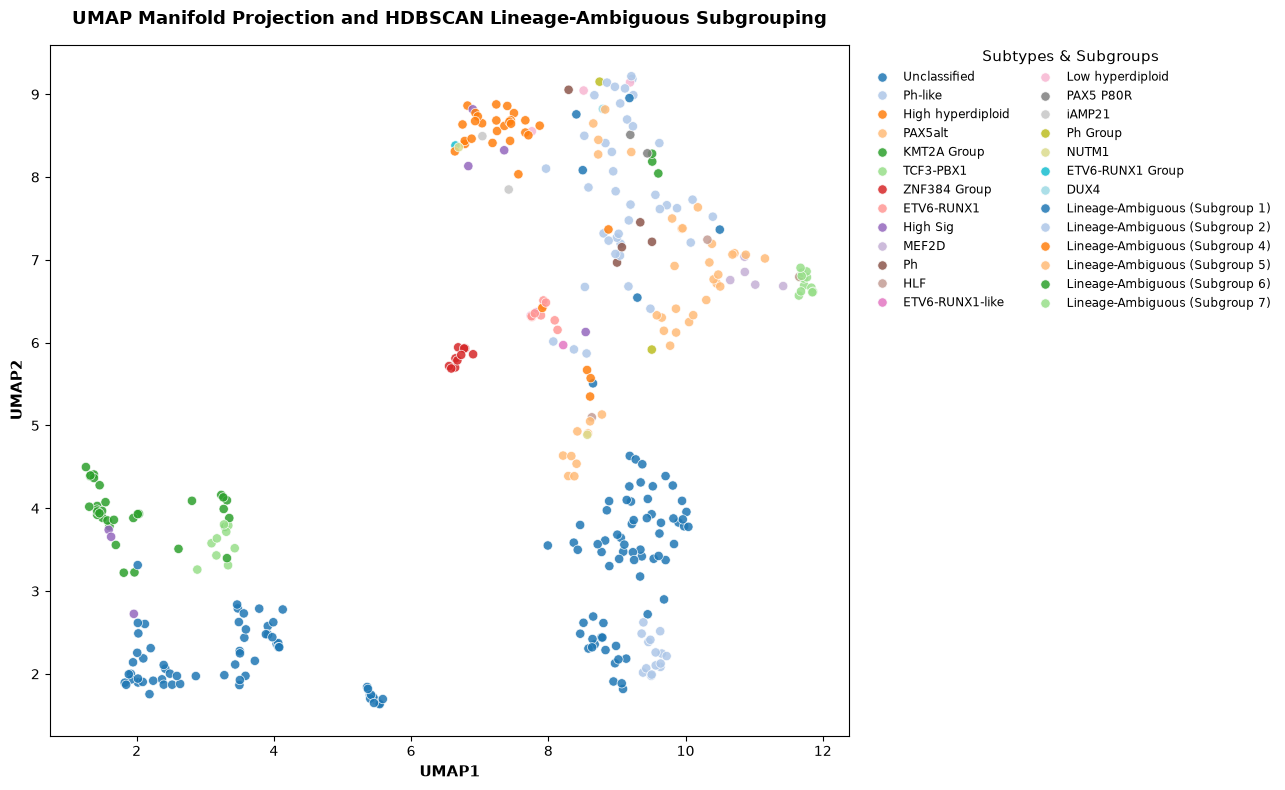

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Order: canonical subtypes first (by frequency), then Lineage-Ambiguous subgroups together at the end
counts = umap_correct_df['thesis_subtype'].value_counts()
canonical = [s for s in counts.index if not s.startswith('Lineage-Ambiguous')]
ambiguous = sorted(
    [s for s in counts.index if s.startswith('Lineage-Ambiguous')],
    key=lambda s: int(s.split('Subgroup ')[1].rstrip(')'))
)
subtype_order = canonical + ambiguous

fig, ax = plt.subplots(figsize=(13, 8))

sns.scatterplot(
    data=umap_correct_df,
    x='UMAP1',
    y='UMAP2',
    hue='thesis_subtype',
    hue_order=subtype_order,     # <-- this is the fix
    palette='tab20',
    s=45,
    alpha=0.85,
    ax=ax
)

ax.set_title("UMAP Manifold Projection and HDBSCAN Lineage-Ambiguous Subgrouping", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("UMAP1", fontsize=11, fontweight='bold')
ax.set_ylabel("UMAP2", fontsize=11, fontweight='bold')

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=False,
    title="Subtypes & Subgroups",
    title_fontsize='11',
    fontsize='8.5',
    ncols=2
)

plt.tight_layout()
plt.savefig("Figure_Thesis_UMAP_QC.png", dpi=300, bbox_inches='tight')
plt.show()

### Table 1: ALLSorts Subtype Distribution
(Full cohort, not restricted to the depth-corrected UMAP subset above.)

In [91]:
subtype_table = meta['subtype'].value_counts().reset_index()
subtype_table.columns = ['Subtype', 'n']

# add a total row
total_row = pd.DataFrame({'Subtype': ['Total'], 'n': [subtype_table['n'].sum()]})
subtype_table = pd.concat([subtype_table, total_row], ignore_index=True)

print(subtype_table)

subtype_table.to_csv('table1_allsorts_subtype_distribution.csv', index=False)

              Subtype    n
0        Unclassified  194
1             Ph-like   40
2   High hyperdiploid   30
3             PAX5alt   29
4         KMT2A Group   14
5           TCF3-PBX1   13
6        ZNF384 Group   10
7          ETV6-RUNX1    9
8            High Sig    7
9               MEF2D    5
10                 Ph    5
11                HLF    3
12    ETV6-RUNX1-like    3
13   Low hyperdiploid    3
14          PAX5 P80R    2
15             iAMP21    2
16           Ph Group    2
17              NUTM1    2
18   ETV6-RUNX1 Group    1
19               DUX4    1
20              Total  375
